# USEPA 2018-19 Exploratory Data Analysis
A variety of data visualization tools were used to analyze the USEPA 2018-2019 NRSA dataset. Most of the EDA was completed with model building in mind. Given that informaton, we are only looking at features that are **remotely-sensed.** This can includes anything that does not require field work to calculate/collect.

E. Reilly Oare

In [1]:
# Read in libs
import os 
import warnings 
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
from scipy.stats import f
from scipy.optimize import curve_fit
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Read EPA 2018-19 datast
trimmed_path = os.path.join(BASE_DIR, "data", "processed", "national", "epa_1819_trimmed.xlsx")
epa_1819 = pd.read_excel(trimmed_path).drop(columns = 'Unnamed: 0')

## Step 2. EDA

### Step 2a. Station embeddedness temporal variation

In [4]:
# Check number of unique stations
epa_1819[['Site ID']].describe()

,Site ID
count,1225
unique,1128
top,NRS18_ND_10001
freq,2


In [5]:
# Identify the Site IDs that appear more than once
stn_count = epa_1819['Site ID'].value_counts()
mult_stn = stn_count[stn_count > 1].index
mult_stn_obj = stn_count[stn_count > 1]

# Create a filtered dataset to only include these Site IDs
multiyr_epa = epa_1819[epa_1819['Site ID'].isin(mult_stn)]

# Display new dataframe
print(f"There are are {multiyr_epa['Site ID'].nunique()} sites that were visited more than once.")
multiyr_epa

There are are 97 sites that were visited more than once.


,Unique ID_x,Site ID,Collection Date,Year,Mean Bank Angle (degrees),Median Bank Angle (Degrees),Mid-channel Canopy Density (%),Bank Canopy Density (%),Constraining Features,% Glide Habitat,...,Total Phosphorus (ug/L),Silica (mg/L),Sodium (mg/L),Sulfate (mg/L),Total Suspended Solids (mg/L),Turbidity (NTU),LAT_DD83,LON_DD83,DIVISION,Bankfull Shear Velocity (m/s)
5,2012492,NRS18_OK_10001,2018-07-16,2018,21.363636,17.5,17.245989,83.422460,HILLSLOPE,32.291667,...,54.000,13.300,39.300,10.300,<5.0,9.40,35.749309,-97.134335,INTERIOR PLAINS,0.109222
9,2012496,NRS18_OK_10050,2018-07-17,2018,28.291667,24.5,0.000000,48.774510,TERRACE,100.000000,...,5.000,11.700,340.000,260.000,<5.0,5.50,35.925819,-99.515246,INTERIOR PLAINS,0.060156
24,2012518,NRS18_TX_10016,2018-06-04,2018,54.500000,52.5,6.016043,49.465241,HUMAN,90.099010,...,3922.250,30.996,105.725,62.582,9.5,4.40,29.910465,-95.491781,ATLANTIC PLAIN,0.055921
33,2012527,NRS18_WV_10010,2018-06-05,2018,21.590909,17.5,89.705882,95.454545,TERRACE,71.287129,...,6.226,5.606,8.045,93.934,1.8,1.92,38.262762,-81.222574,APPALACHIAN HIGHLANDS,0.283367
34,2012528,NRS18_OK_10001,2018-06-04,2018,30.590909,28.0,12.566845,78.074866,TERRACE,72.380952,...,143.000,14.000,18.200,4.830,24,29.60,35.749309,-97.134335,INTERIOR PLAINS,0.094035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,2014651,NRS18_ME_10001,2019-09-15,2019,17.678571,15.0,100.000000,99.789916,HILLSLOPE,13.333333,...,10.891,5.325,1.337,1.337,0.6,1.69,46.975564,-69.378381,APPALACHIAN HIGHLANDS,0.348099
1193,2014659,NRS18_KS_10012,2019-09-16,2019,26.714286,22.0,79.010695,96.078431,TERRACE,85.000000,...,26.768,8.710,15.167,25.838,4.1,3.99,37.209705,-95.545391,INTERIOR PLAINS,0.092637
1198,2014670,NRS18_KS_10029,2019-09-17,2019,34.363636,36.5,52.540107,82.352941,TERRACE,100.000000,...,245.968,15.874,22.074,125.851,26.9,13.58,39.754473,-95.699033,INTERIOR PLAINS,0.050627
1199,2014671,NRS18_SD_10006,2019-09-17,2019,59.363636,59.0,10.828877,81.232493,TERRACE,10.000000,...,207.085,13.993,84.729,79.451,884,3718.00,45.563228,-101.548717,INTERIOR PLAINS,0.143304


In [6]:
# Turn multiple station series into a dataframe
mult_stn_df = mult_stn_obj.to_frame()

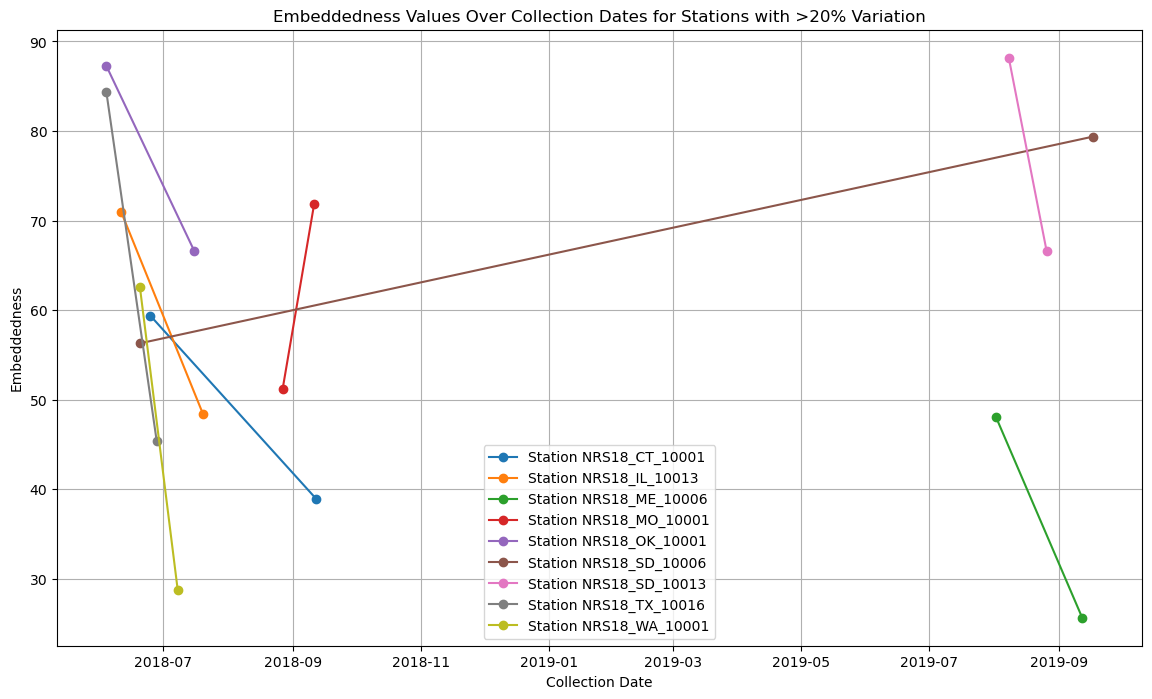

,Site ID,min,max,Mean streambed embeddedness (%) pct change
80,NRS18_TX_10016,45.363636,84.363636,39.000000
88,NRS18_WA_10001,28.750000,62.545455,33.795455
75,NRS18_SD_10006,56.282051,79.363636,23.081585
19,NRS18_IL_10013,48.418182,71.000000,22.581818
31,NRS18_ME_10006,25.636364,48.000000,22.363636
...,...,...,...,...
65,NRS18_OK_10050,100.000000,100.000000,0.000000
15,NRS18_IA_10001,100.000000,100.000000,0.000000
73,NRS18_SC_10007,100.000000,100.000000,0.000000
18,NRS18_IL_10001,100.000000,100.000000,0.000000


In [7]:
# Reset index
if 'Site ID' in multiyr_epa.index.names:
    multiyr_epa.reset_index(inplace=True, drop=True)

# Calculate the minimum and maximum embeddedness values for each site
min_max_values = multiyr_epa.groupby('Site ID')['Mean streambed embeddedness (%)'].agg(['min', 'max']).reset_index()

# Calculate the overall percentage change from min to max for each site
min_max_values['Mean streambed embeddedness (%) pct change'] = (min_max_values['max'] - min_max_values['min']).abs()

# Identify the stations that have more than given variation
variation_threshold = 20
stations_with_high_variation = min_max_values[min_max_values['Mean streambed embeddedness (%) pct change'] >= variation_threshold]['Site ID'].unique()

# Plot the mean streambed embeddedness values over the dates
plt.figure(figsize=(14, 8))
for station in stations_with_high_variation:
    station_data = multiyr_epa[multiyr_epa['Site ID'] == station]
    plt.plot(station_data['Collection Date'], station_data['Mean streambed embeddedness (%)'], marker='o', label=f'Station {station}')

plt.xlabel('Collection Date')
plt.ylabel('Embeddedness')
plt.title(f'Embeddedness Values Over Collection Dates for Stations with >{variation_threshold}% Variation')
plt.legend()
plt.grid(True)
plt.legend()
plt.show()

# Display dataframe with % change shown
min_max_values.sort_values(by = ['Mean streambed embeddedness (%) pct change'],
                           ascending = False)

Some observations:
- No sites were visited >2 times for this dataset (expected given 2 yr dataset)
- The sites that were visited multiple times were usually visited within a month (other than SD_10006)
- The % changes plotted were >20% change in embeddedness.
- It's surprising that they saw so many sites change >20% within a month, although 7/8 sites visited in the same year saw decreases in embeddedness.

<br>From this dataset alone, we cannot conclude much information. However, in the future, we can look at other datasets or wait for the newest NRSA dataset.

### Step 2b. Correlation EDA
We'll use Spearman's correlation coefficient since it is a nonparametric measure of rank correlation using a monotonic function. We can first look at the full dataset, then we will only focus on variables that are remotely calculated/derived to ensure we make the model as accessible and usable as possible.

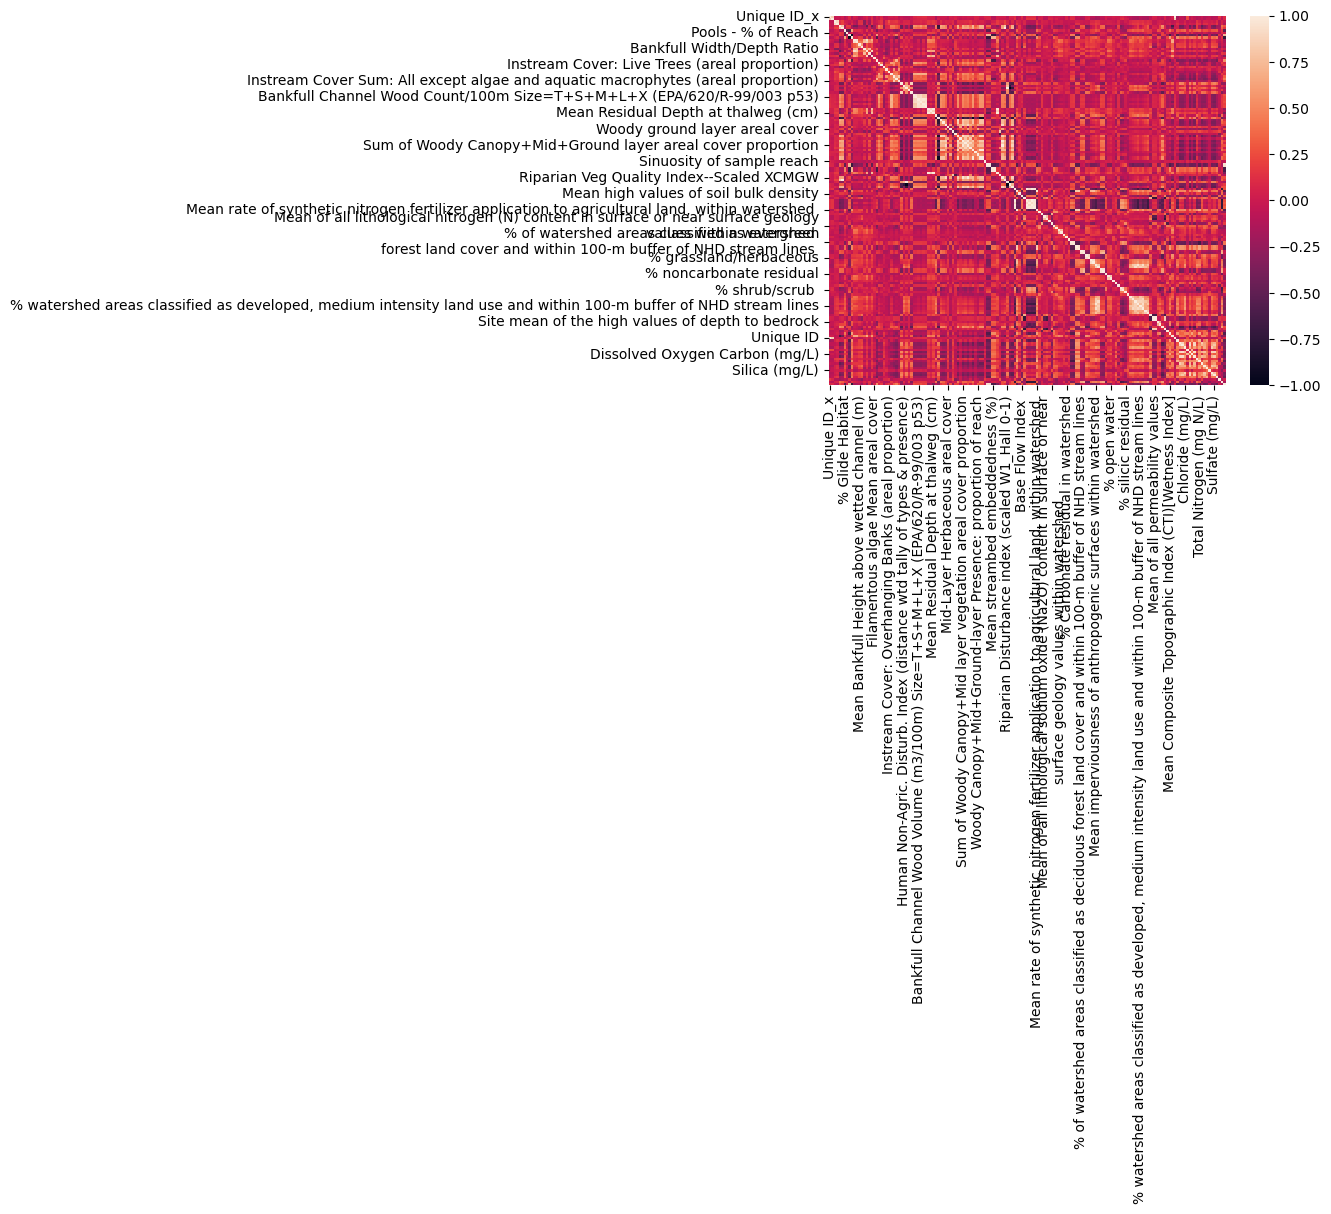

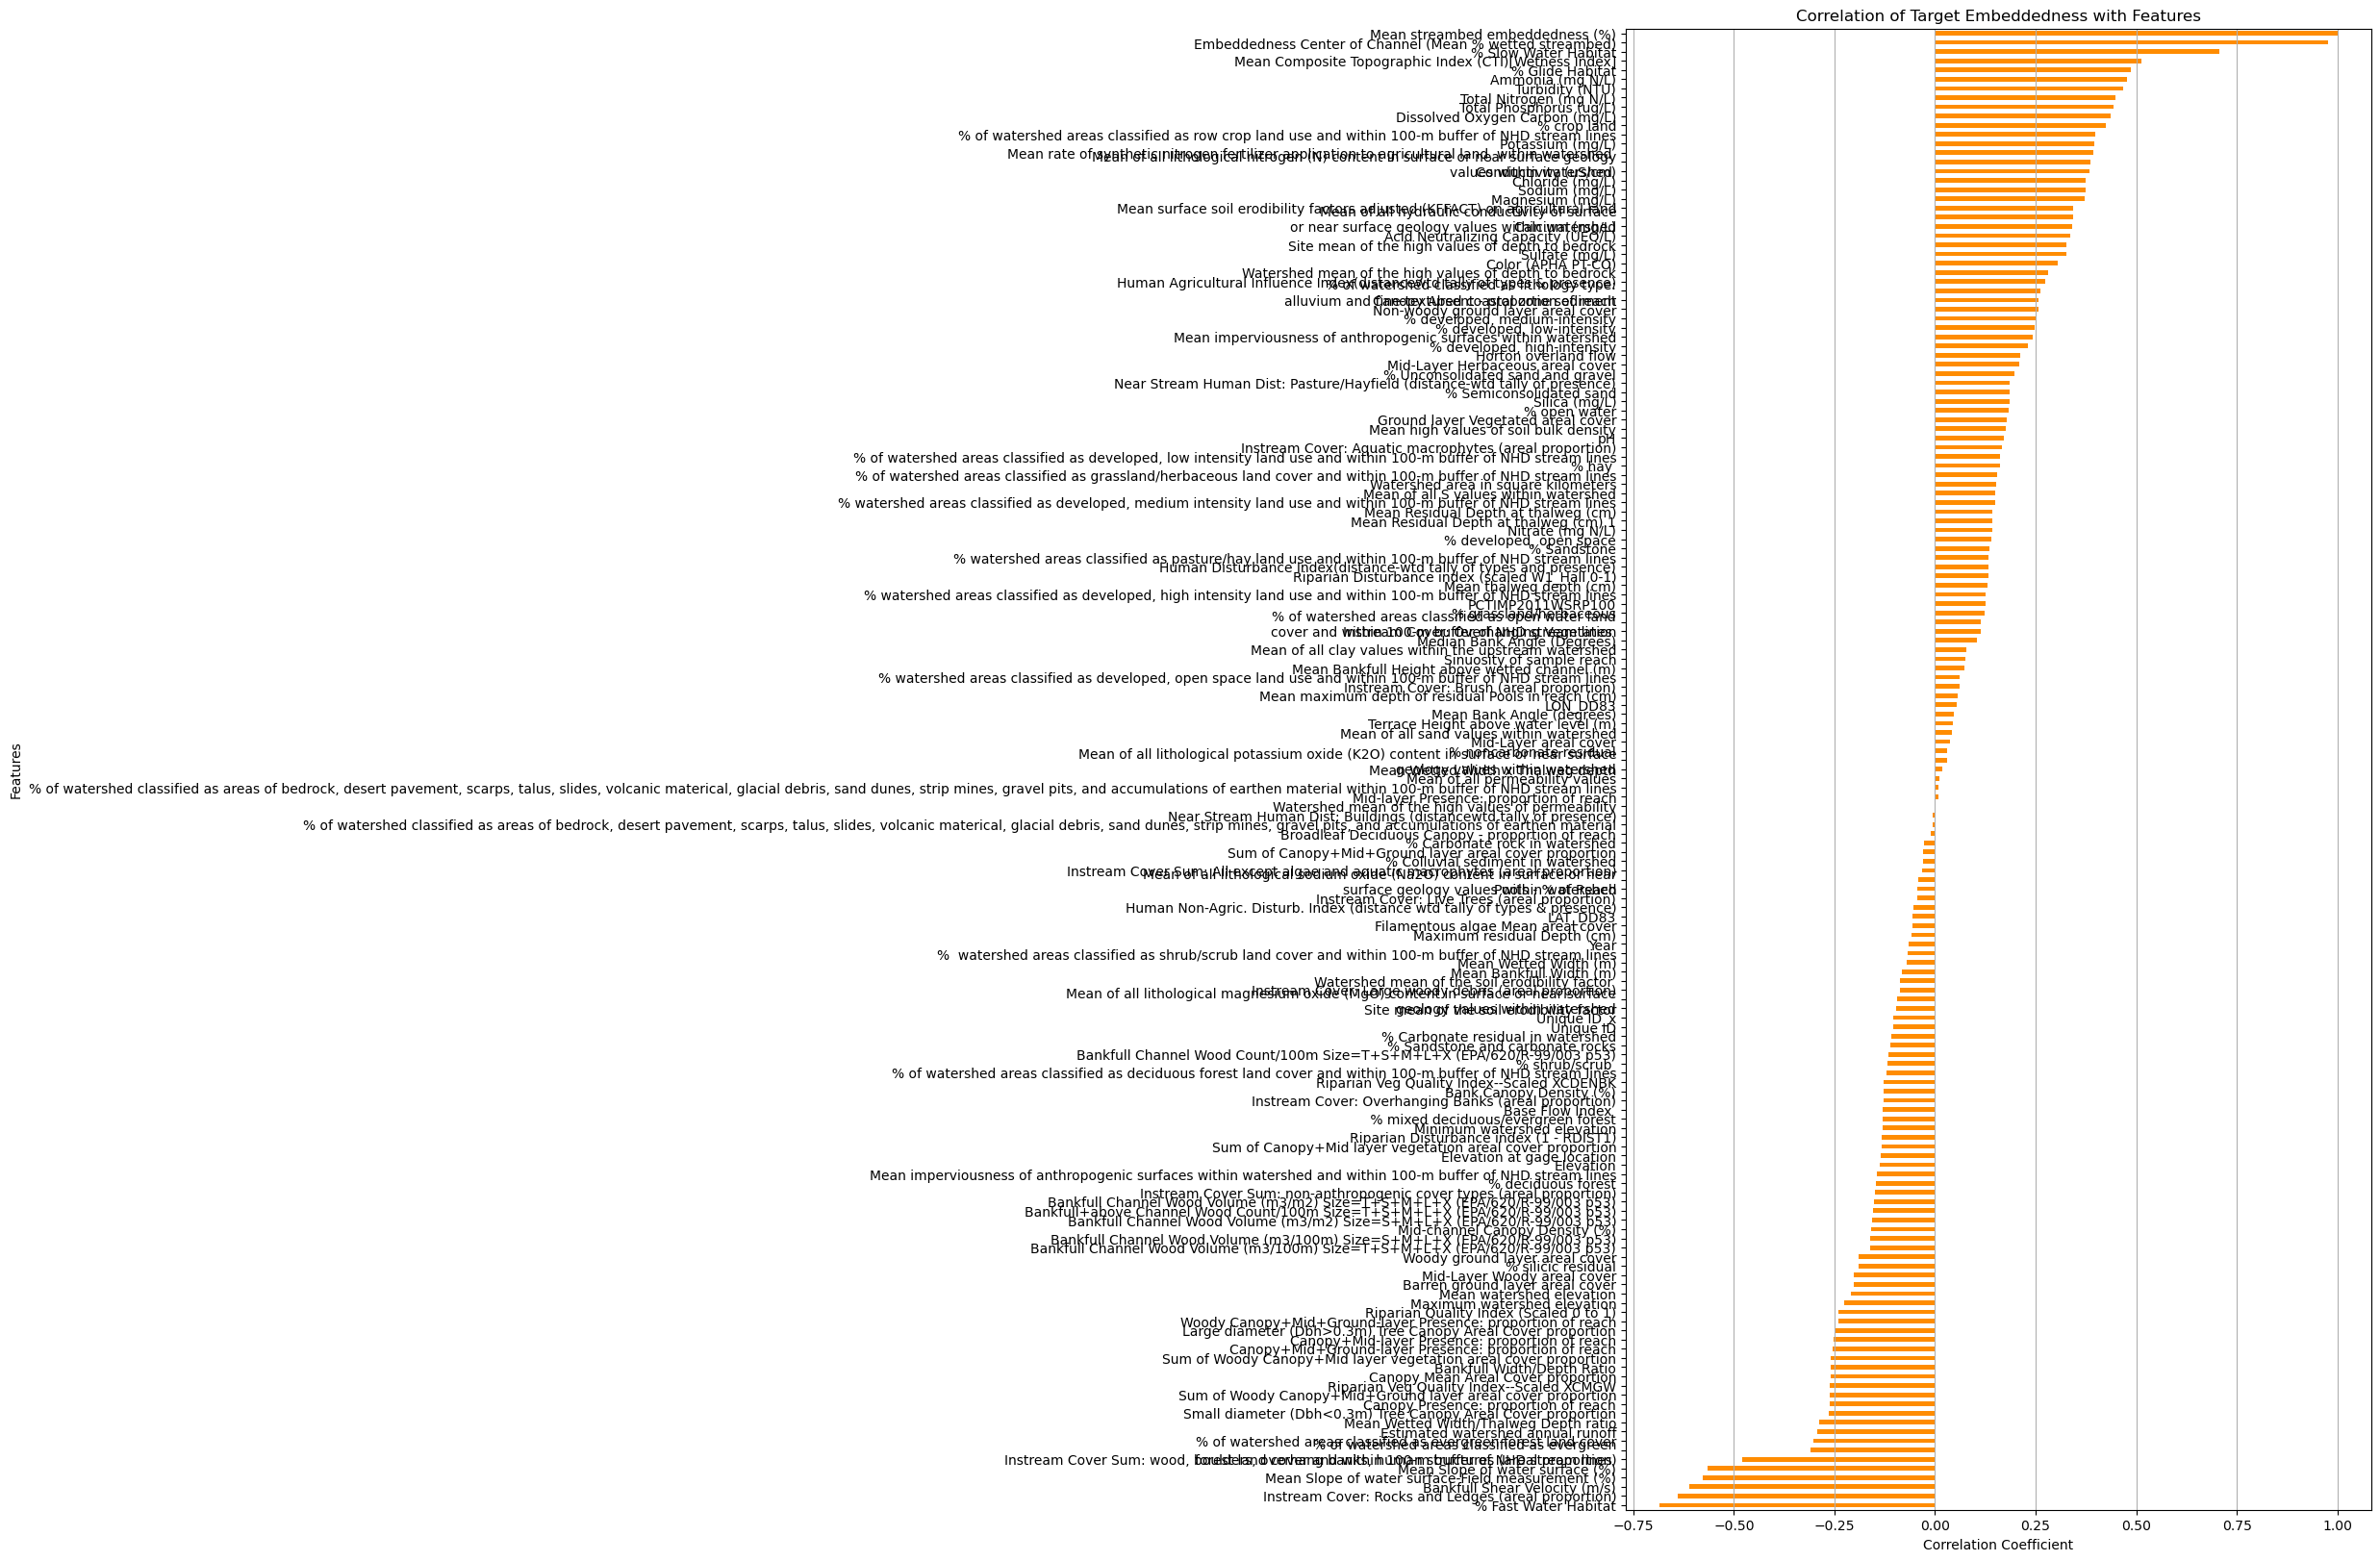

In [8]:
# Create correlation matrix and heatmap

# Select for only numerical values
num_df = epa_1819.select_dtypes(include = 'number')
corr = num_df.corr(method = 'spearman')
# Print heatmap
sns.heatmap(corr)

# Select for target
target_corr = corr.loc['Mean streambed embeddedness (%)'].sort_values()

# Plot the horizontal bar plot
plt.figure(figsize=(10, 20))
target_corr.plot(kind='barh', color='darkorange')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title(f'Correlation of Target Embeddedness with Features')
plt.grid(axis='x')

# Show figure
plt.show()

In [9]:
# Select for top 40 correlations
abs_corr = target_corr.abs().sort_values(ascending = False)
top40_series = abs_corr[:41]

# Find intersection between subset and full correlation matrix
common_indices = corr.index.intersection(top40_series.index)
top40_corr = corr.loc[common_indices, common_indices]
pd.set_option('display.max_rows', 50) # To see all correlations
pd.set_option('display.max_columns', 50) # To see all correlations in dataframe format
top40_series

Mean streambed embeddedness (%)                                                                                 1.000000
Embeddedness Center of Channel (Mean % wetted streambed)                                                        0.976048
% Slow Water Habitat                                                                                            0.705636
% Fast Water Habitat                                                                                            0.684738
Instream Cover: Rocks and Ledges (areal proportion)                                                             0.638512
Bankfull Shear Velocity (m/s)                                                                                   0.612048
Mean Slope of water surface-Field measurement (%)                                                               0.578431
Mean Slope of water surface (%)                                                                                 0.565517
Mean Composite Topographic Index

Major Takeaways from initial correlation analysis:
- Some field data, like slow/fast water habitat, correlates very well to embeddedness (expected given the dependence on sediment transport processes).
- Bankfull shear velocity has a coefficient of 0.61 which is close to what we expected.
- A lot of chemical measurements (ammonia, turbidity, total nitrogen) have relatively high correlations.
- Some soil characteristics (watershed-level) are higher too.
- The only channel characteristic we got was 'Mean Wetted Width/Thalweg Depth ratio'

For now, we will delete anything *not* remotely-derived for the sake of model building, and we'll use this for the rest of the EDA.

In [10]:
# Drop all non-remotely-derived data
epa_1819_trim = epa_1819.drop(columns = ['Mean Bank Angle (degrees)',
                                         'Median Bank Angle (Degrees)',
                                         'Mid-channel Canopy Density (%)',
                                         'Bank Canopy Density (%)',
                                         'Constraining Features',
                                         '% Glide Habitat',
                                         'Pools - % of Reach',
                                         '% Fast Water Habitat',
                                         '% Slow Water Habitat',
                                         'Mean Wetted Width (m)',
                                         'Mean Bankfull Width (m)',
                                         'Mean Bankfull Height above wetted channel (m)',
                                         'Terrace Height above water level (m)',
                                         'Bankfull Width/Depth Ratio',
                                         'Mean Wetted Width x Thalweg depth',
                                         'Mean Wetted Width/Thalweg Depth ratio',
                                         'Mean thalweg depth (cm)',
                                         'Filamentous algae Mean areal cover',
                                         'Instream Cover: Rocks and Ledges (areal proportion)',
                                         'Instream Cover: Brush (areal proportion)',
                                         'Instream Cover: Live Trees (areal proportion)',
                                         'Instream Cover: Aquatic macrophytes (areal proportion)',
                                         'Instream Cover: Overhanging Vegetation',
                                         'Instream Cover: Overhanging Banks (areal proportion)',
                                         'Instream Cover: Large woody debris (areal proportion)',
                                         'Instream Cover Sum: non-anthropogenic cover types (areal proportion)',
                                         'Instream Cover Sum: wood, boulders, overhang banks, human structures (areal proportion)',
                                         'Instream Cover Sum: All except algae and aquatic macrophytes (areal proportion)',
                                         'Human Agricultural Influence Index(distancewtd tally of types & presence)',
                                         'Human Non-Agric. Disturb. Index (distance wtd tally of types & presence)',
                                         'Human Disturbance Index(distance-wtd tally of types and presence)',
                                         'Near Stream Human Dist: Buildings (distancewtd tally of presence)',
                                         'Near Stream Human Dist: Pasture/Hayfield (distance-wtd tally of presence)',
                                         'Bankfull+above Channel Wood Count/100m Size=T+S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Bankfull Channel Wood Count/100m Size=T+S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Bankfull Channel Wood Volume (m3/100m) Size=T+S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Bankfull Channel Wood Volume (m3/m2) Size=T+S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Bankfull Channel Wood Volume (m3/100m) Size=S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Bankfull Channel Wood Volume (m3/m2) Size=S+M+L+X (EPA/620/R-99/003 p53)',
                                         'Mean maximum depth of residual Pools in reach (cm)',
                                         'Maximum residual Depth (cm)',
                                         'Mean Residual Depth at thalweg (cm)',
                                         'Broadleaf Deciduous Canopy - proportion of reach',
                                         'Canopy Absent - proportion of reach',
                                         'Large diameter (Dbh>0.3m) Tree Canopy Areal Cover proportion',
                                         'Small diameter (Dbh<0.3m) Tree Canopy Areal Cover proportion',
                                         'Mid-Layer Woody areal cover',
                                         'Mid-Layer Herbaceous areal cover',
                                         'Woody ground layer areal cover',
                                         'Non-woody ground layer areal cover',
                                         'Barren ground layer areal cover',
                                         'Canopy Mean Areal Cover proportion',
                                         'Mid-Layer areal cover',
                                         'Sum of Woody Canopy+Mid layer vegetation areal cover proportion',
                                         'Sum of Canopy+Mid layer vegetation areal cover proportion',
                                         'Sum of Woody Canopy+Mid+Ground layer areal cover proportion',
                                         'Sum of Canopy+Mid+Ground layer areal cover proportion',
                                         'Canopy Presence: proportion of reach',
                                         'Mid-layer Presence: proportion of reach',
                                         'Woody Canopy+Mid+Ground-layer Presence: proportion of reach',
                                         'Canopy+Mid-layer Presence: proportion of reach',
                                         'Canopy+Mid+Ground-layer Presence: proportion of reach',
                                         'Sinuosity of sample reach',
                                         'Mean Slope of water surface-Field measurement (%)',
                                         'Embeddedness Center of Channel (Mean % wetted streambed)',
                                         'Mean Residual Depth at thalweg (cm).1',
                                         'Ground layer Vegetated areal cover',
                                         'Riparian Veg Quality Index--Scaled XCMGW',
                                         'Riparian Veg Quality Index--Scaled XCDENBK',
                                         'Riparian Disturbance index (scaled W1_Hall 0-1)',
                                         'Riparian Disturbance index (1 - RDIST1)',
                                         'Riparian Quality Index (Scaled 0 to 1)',
                                         'Ammonia (mg N/L)',
                                         'Acid Neutralizing Capacity (UEQ/L)',
                                         'Calcium (mg/L)',
                                         'Chloride (mg/L)',
                                         'Color (APHA PT-CO)',
                                         'Conductivity (uS/cm)',
                                         'Dissolved Oxygen Carbon (mg/L)',
                                         'Magnesium (mg/L)',
                                         'Nitrate (mg N/L)',
                                         'Total Nitrogen (mg N/L)',
                                         'pH',
                                         'Potassium (mg/L)',
                                         'Total Phosphorus (ug/L)',
                                         'Silica (mg/L)',
                                         'Sodium (mg/L)',
                                         'Sulfate (mg/L)',
                                         'Total Suspended Solids (mg/L)',
                                         'Turbidity (NTU)'])

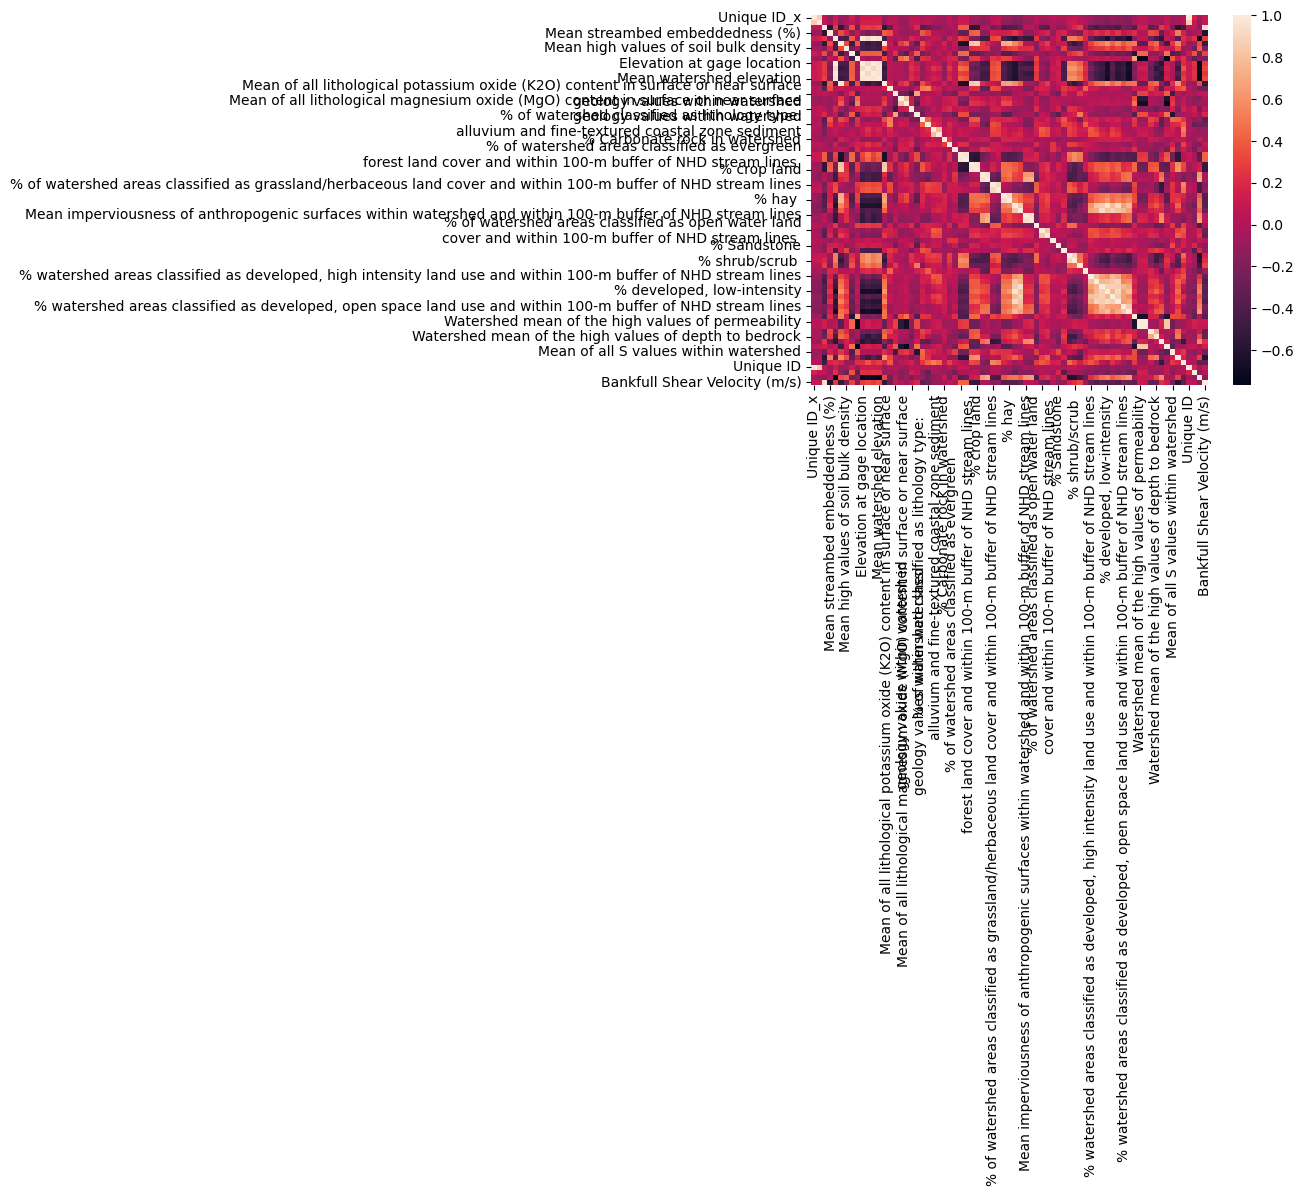

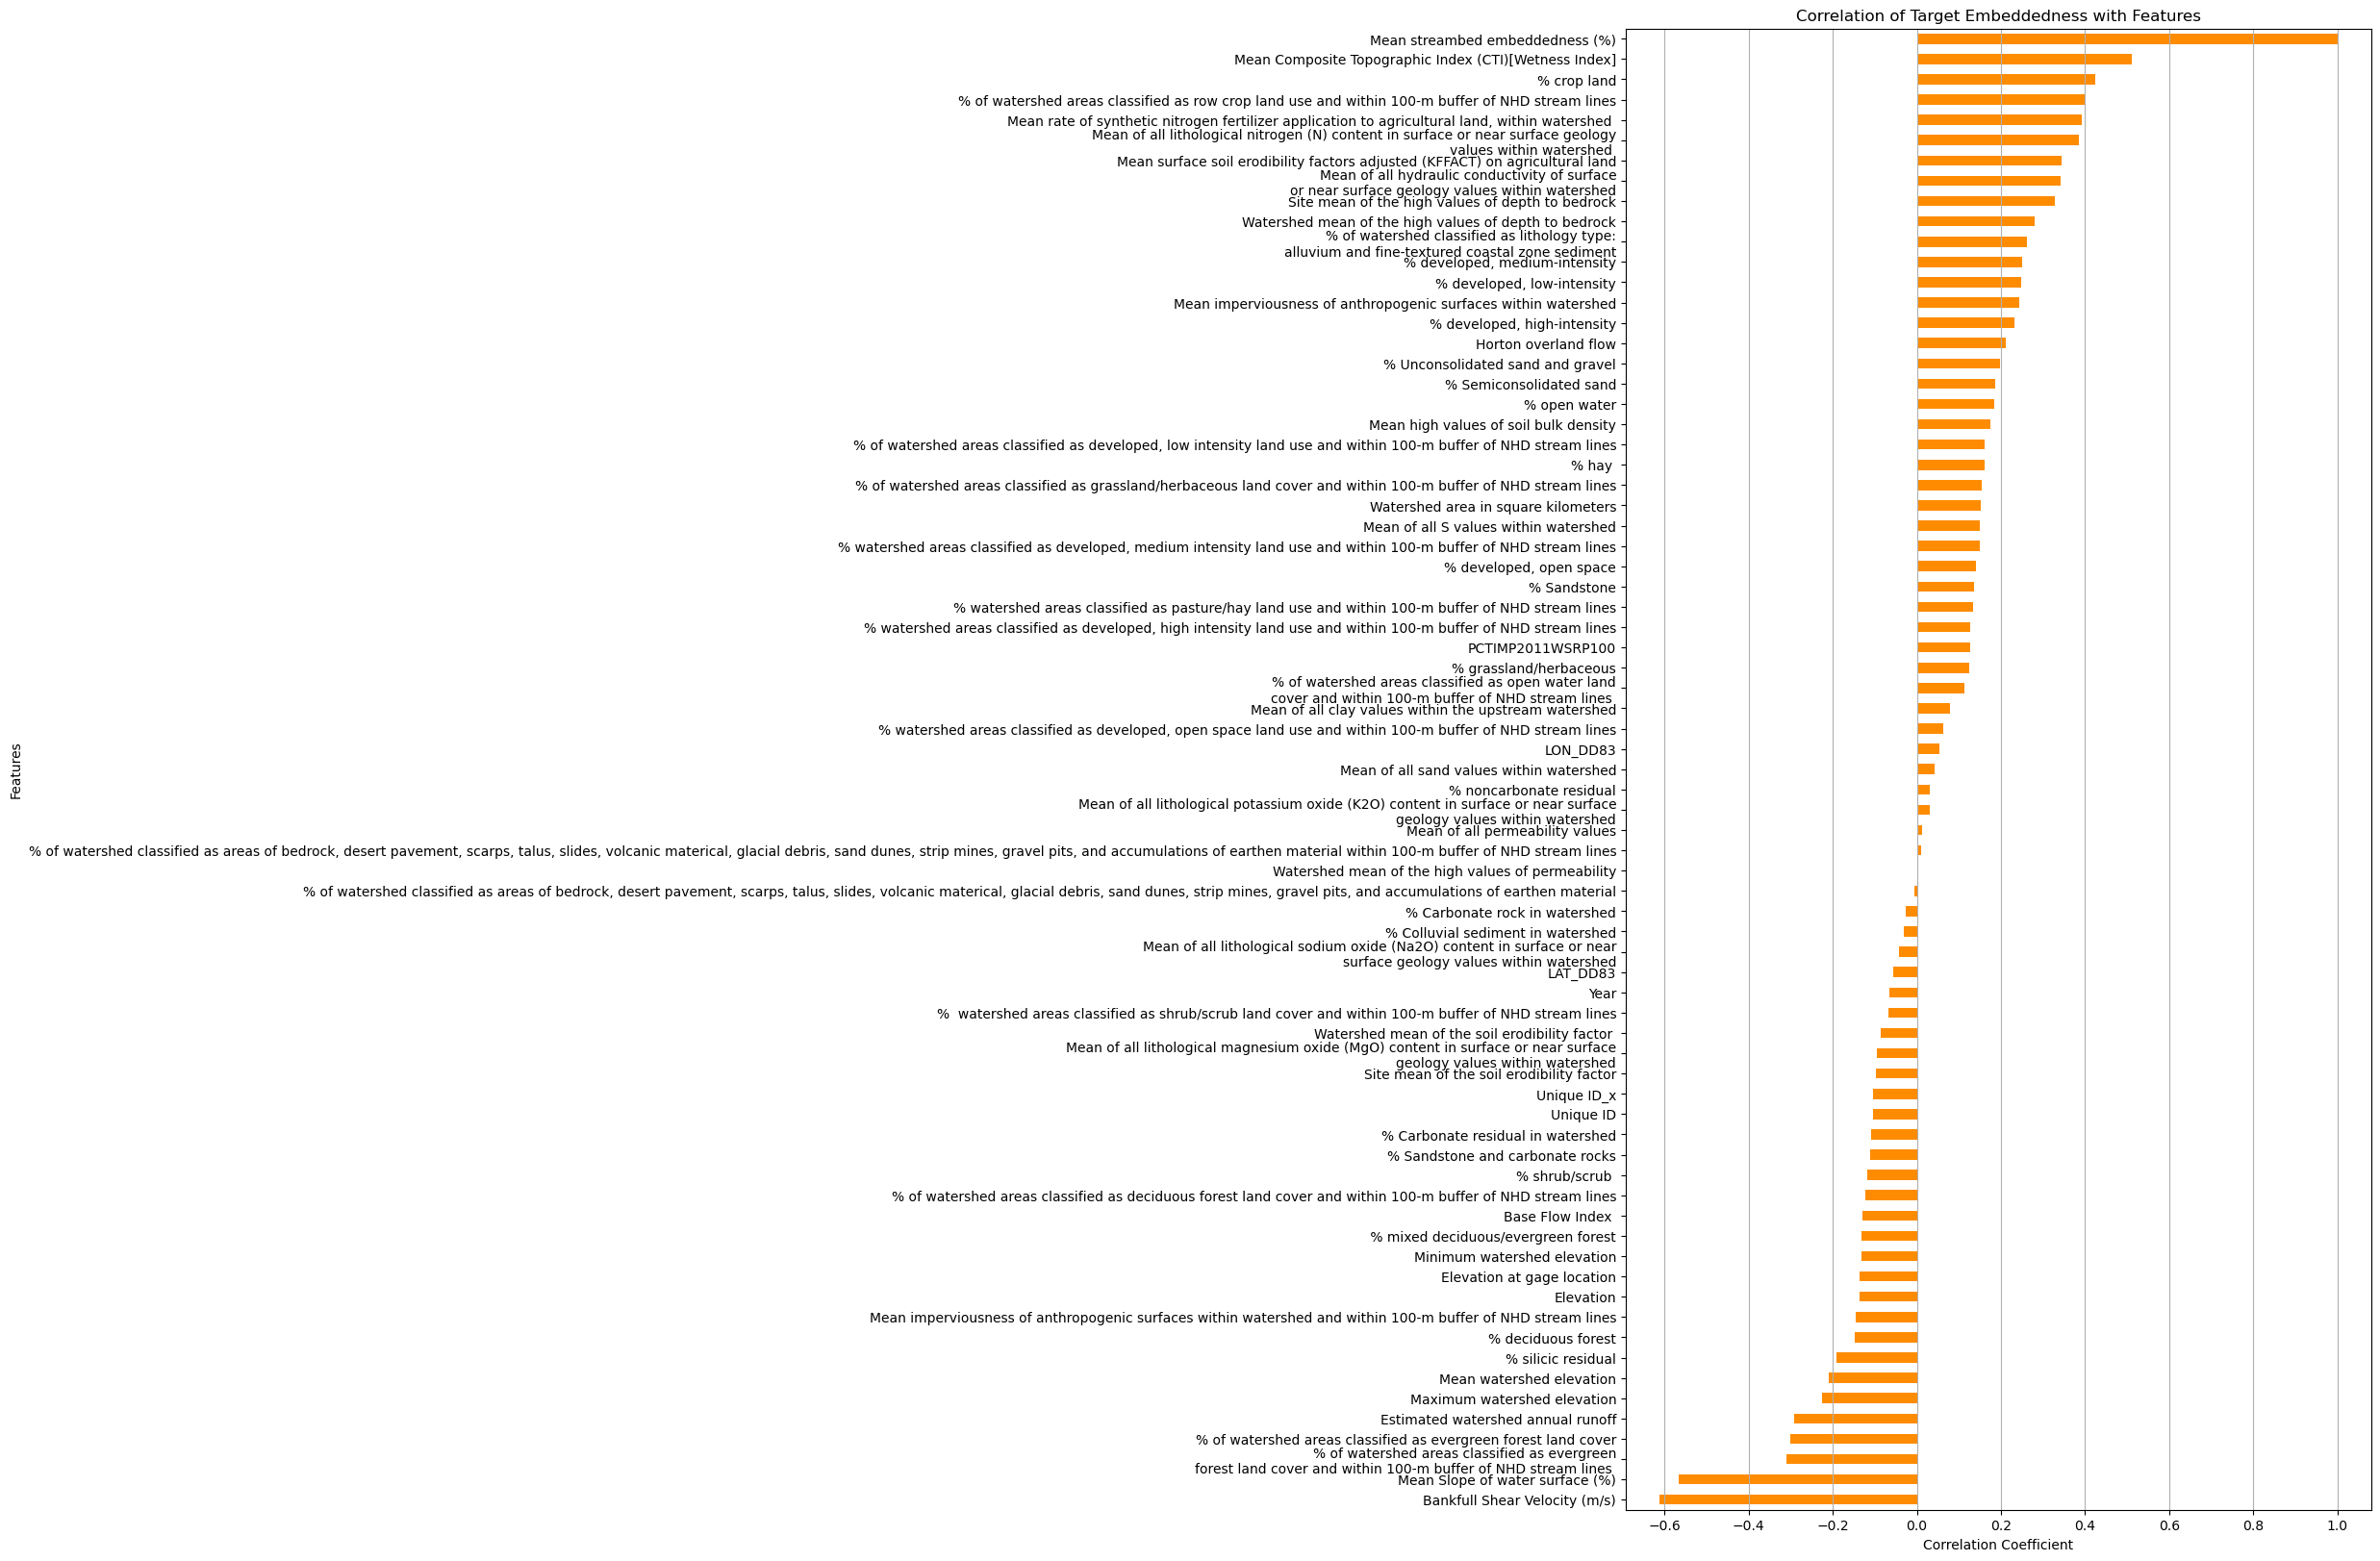

In [11]:
# Create new correlation  matrix (removed field data)

# Select for only numerical values
num_df = epa_1819_trim.select_dtypes(include = 'number')
corr = num_df.corr(method = 'spearman')
# Print heatmap
sns.heatmap(corr)

# Select for target
target_corr = corr.loc['Mean streambed embeddedness (%)'].sort_values()

# Plot the horizontal bar plot
plt.figure(figsize=(10, 20))
target_corr.plot(kind='barh', color='darkorange')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title(f'Correlation of Target Embeddedness with Features')
plt.grid(axis='x')
plt.show()

In [12]:
# Select for top 40 correlations
abs_corr = target_corr.abs().sort_values(ascending = False)
top40_series = abs_corr[:41]

# Find intersection between subset and full correlation matrix
common_indices = corr.index.intersection(top40_series.index)
top40_corr = corr.loc[common_indices, common_indices]

# Print top 40 corrs (absolute value)
top40_series

Mean streambed embeddedness (%)                                                                                     1.000000
Bankfull Shear Velocity (m/s)                                                                                       0.612048
Mean Slope of water surface (%)                                                                                     0.565517
Mean Composite Topographic Index (CTI)[Wetness Index]                                                               0.512233
% crop land                                                                                                         0.425229
% of watershed areas classified as row crop land use and within 100-m buffer of NHD stream lines                    0.398180
Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed                       0.393099
Mean of all lithological nitrogen (N) content in surface or near surface geology\nvalues within watershed           0.385233


Major Takeaways from correlations with only remotely derived:
- Bankfull shear velocity is still near the top! We can derive this remotely (shown in Czuba et al., 2022).
- Land uses are also showing up as highly correlated, as in the VA model.
- Some geologic characteristics also showed up.

Now, we'll work to reduce multicolinearty in the highest correlations.

,Mean Slope of water surface (%),Mean streambed embeddedness (%),Elevation,Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land,Mean high values of soil bulk density,Elevation at gage location,Maximum watershed elevation,Mean watershed elevation,"Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed",Mean of all hydraulic conductivity of surface\nor near surface geology values within watershed,Mean of all lithological nitrogen (N) content in surface or near surface geology\nvalues within watershed,% of watershed classified as lithology type:\nalluvium and fine-textured coastal zone sediment,% of watershed areas classified as evergreen\nforest land cover and within 100-m buffer of NHD stream lines,% of watershed areas classified as evergreen forest land cover,% of watershed areas classified as row crop land use and within 100-m buffer of NHD stream lines,% crop land,% deciduous forest,% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,% watershed areas classified as pasture/hay land use and within 100-m buffer of NHD stream lines,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines,% open water,% Sandstone,% Semiconsolidated sand,% silicic residual,% Unconsolidated sand and gravel,"% developed, high-intensity","% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines","% developed, low-intensity","% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines","% developed, medium-intensity","% developed, open space",Horton overland flow,Site mean of the high values of depth to bedrock,Watershed mean of the high values of depth to bedrock,Estimated watershed annual runoff,Mean of all S values within watershed,Mean Composite Topographic Index (CTI)[Wetness Index],Watershed area in square kilometers,Bankfull Shear Velocity (m/s)
Mean Slope of water surface (%),1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.951593
Mean streambed embeddedness (%),NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Elevation,NaN,NaN,1.000000,NaN,NaN,0.999521,0.904755,0.965015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land,NaN,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,0.96893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean high values of soil bulk density,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Elevation at gage location,NaN,NaN,0.999521,NaN,NaN,1.000000,0.904206,0.964834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maximum watershed elevation,NaN,NaN,0.904755,NaN,NaN,0.904206,1.000000,0.975923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean watershed elevation,NaN,NaN,0.965015,NaN,NaN,0.964834,0.975923,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed",NaN,NaN,NaN,0.96893,NaN,NaN,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

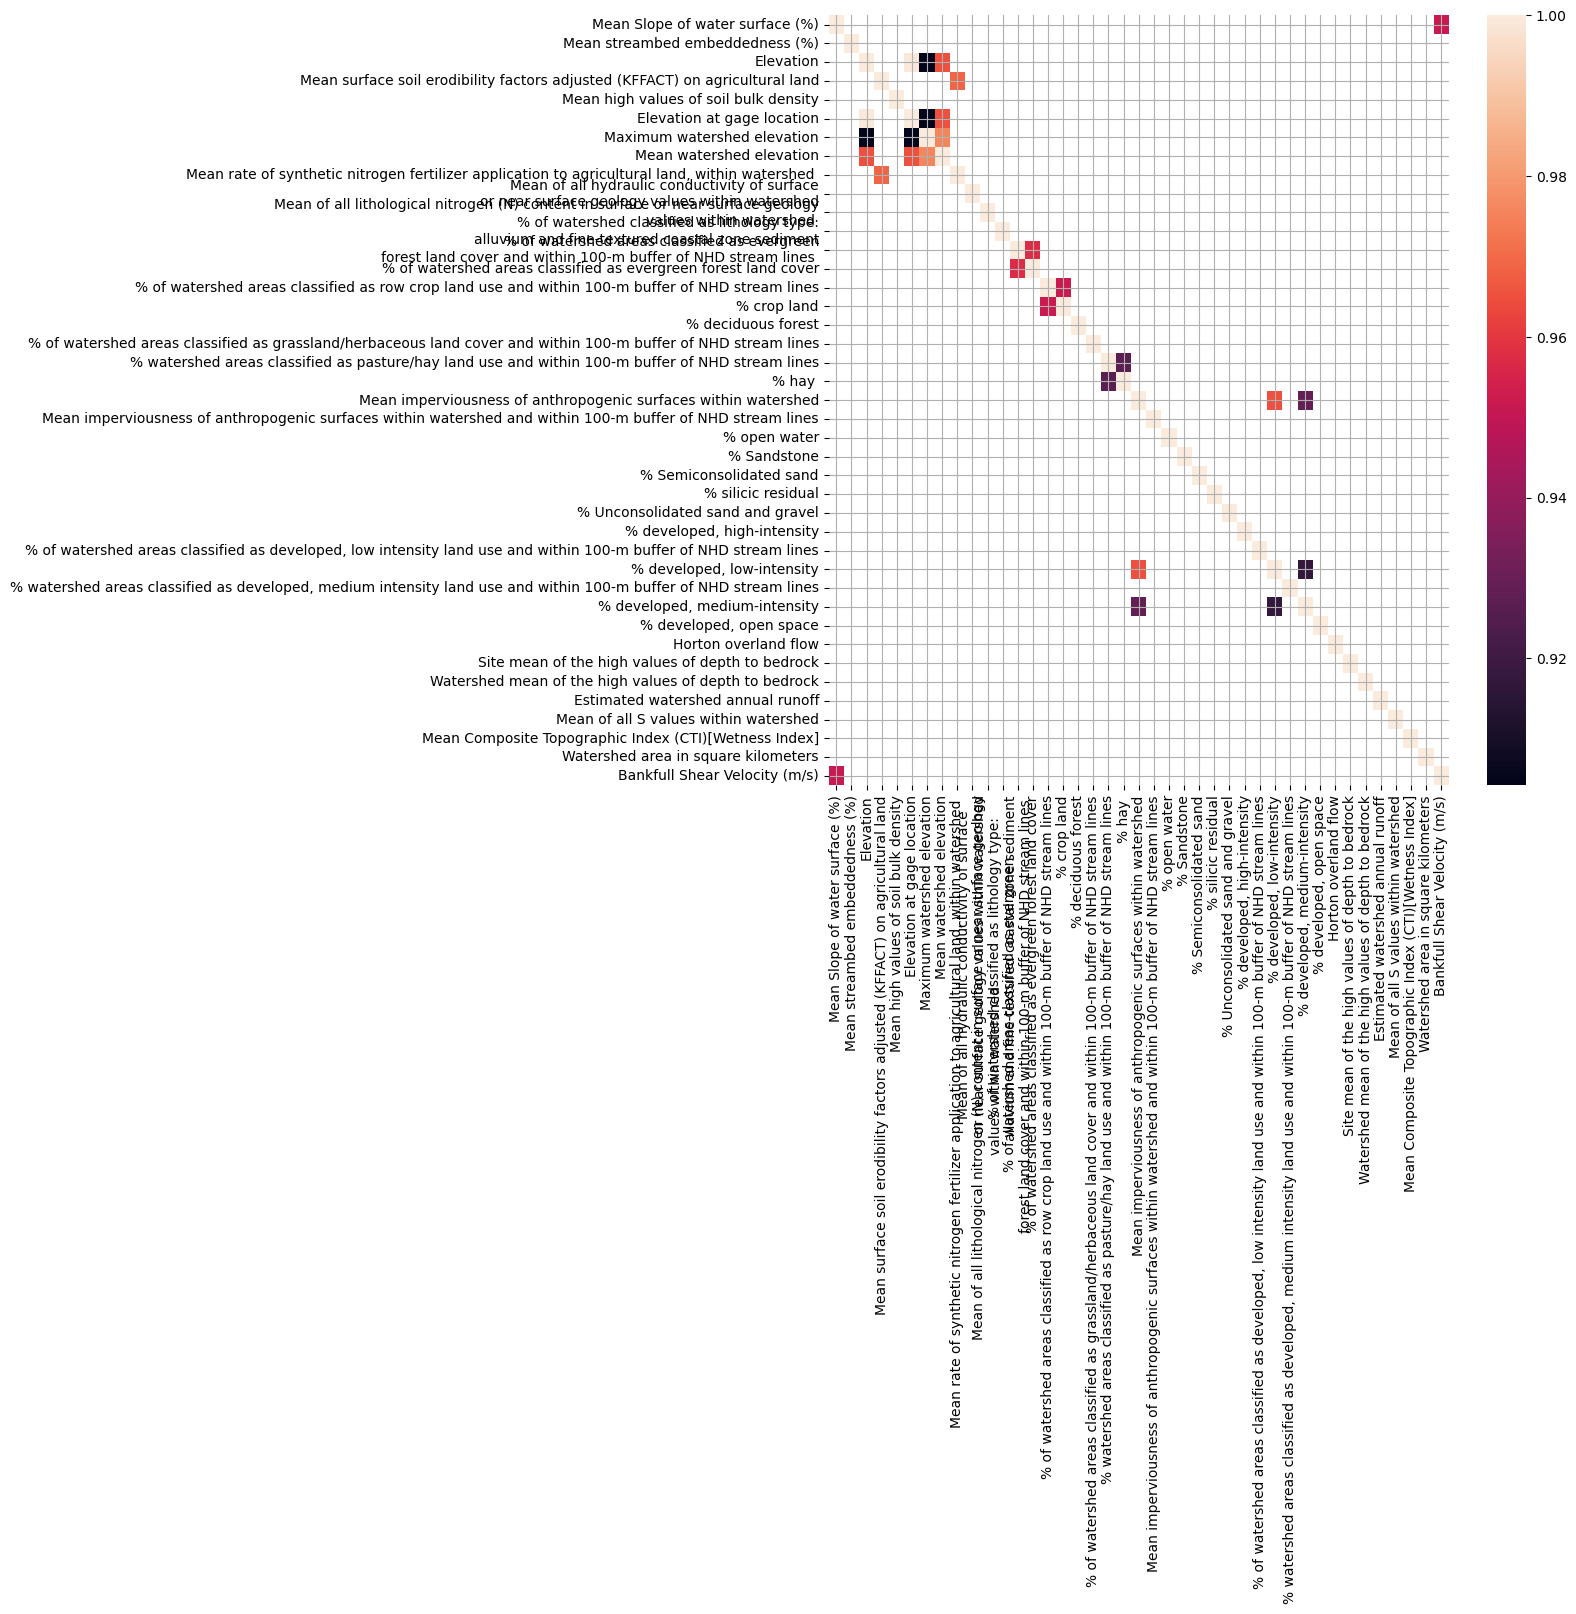

In [13]:
# Set a threshold for filtering based on absolute value
threshold = 0.9

# Keep values greater than 0.9 or less than -0.9
filtered_corr1 = top40_corr.where(top40_corr.abs() > threshold)

# Display results
plt.figure(figsize=(10, 10))
sns.heatmap(filtered_corr1)
plt.grid(True)
filtered_corr1

##### Pairings with correlations above 0.9:
1. 'Elevation at gage location' & 'Elevation'
2. 'Maximum watershed elevation' & 'Elevation'
3. 'Mean watershed elevation' & 'Elevation'
4. 'Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed' & 'Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land'
5. 'Maximum watershed elevation' & 'Elevation at gage location'
6. 'Mean watershed elevation' & 'Elevation at gage location'
7. 'Mean watershed elevation' & 'Maximum watershed elevation'
8. '% of watershed areas classified as evergreen forest land cover' & '% of watershed areas classified as evergreen\nforest land cover and within 100-m buffer of NHD stream lines'
9. '% crop land' & '% of watershed areas classified as row crop land use and within 100-m buffer of NHD stream lines'
10. '% hay' & '% watershed areas classified as pasture/hay land use and within 100-m buffer of NHD stream lines'
11. '% developed, low-intensity' & 'Mean imperviousness of anthropogenic surfaces within watershed'
12. '% developed, medium-intensity' & 'Mean imperviousness of anthropogenic surfaces within watershed'
13. '% developed, medium-intensity' & '% developed, low-intensity'
14. 'Bankfull Shear Velocity (m/s)' & 'Mean Slope of water surface (%)'

**Therefore, we will drop...**
1. 'Elevation at gage location' --> interested in watershed characteristics and has lower corr
3. 'Elevation' --> lower corr than mean watershed
4. 'Maximum watershed elevaton' --> want to focus on an average watershed elevation
5. 'Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed' --> Oddly specfic calculation/measurement that is less key than soil erodibility
6. '% of watershed areas classified as evergreen\nforest land cover and within 100-m buffer of NHD stream lines' --> remove and keep watershed level
7. '% of watershed areas classified as row crop land use and within 100-m buffer of NHD stream lines' --> remove and keep watershed level
8. '% watershed areas classified as pasture/hay land use and within 100-m buffer of NHD stream lines' --> remove and keep watershed level
9. '% developed, low-intensity' --> Used to calculate impervious surface
10. '% developed, medium-intensity' --> Used to calculate impervious surface
11. 'Mean Slope of water surface (%)' --> We would require bankfull depth to calculate, which is generally the most difficult to estimate remotely. Slope is highly correlated, so it will have to serve as a proxy.

In [14]:
# Standardize column names by stripping spaces and newlines
top40_corr.columns = top40_corr.columns.str.strip().str.replace("\n", " ")
top40_corr.index = top40_corr.index.str.strip().str.replace("\n", " ")

# Define the list of index rows and columns to drop
to_drop = ['Elevation at gage location',
        'Elevation',
        'Maximum watershed elevation',
        'Mean rate of synthetic nitrogen fertilizer application to agricultural land, within watershed',
        '% of watershed areas classified as evergreen forest land cover and within 100-m buffer of NHD stream lines',
        '% of watershed areas classified as row crop land use and within 100-m buffer of NHD stream lines',
        '% watershed areas classified as pasture/hay land use and within 100-m buffer of NHD stream lines',
        '% developed, low-intensity',
        '% developed, medium-intensity',
        'Mean Slope of water surface (%)']

# Drop specified index rows and columns
top40_drp1 = top40_corr.drop(index = [i for i in to_drop], 
                             columns = [c for c in to_drop])

# Display updated DataFrame shape (check they were all dropped)
top40_drp1.shape

(31, 31)

,Mean streambed embeddedness (%),Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land,Mean high values of soil bulk density,Mean watershed elevation,Mean of all hydraulic conductivity of surface or near surface geology values within watershed,Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,% of watershed areas classified as evergreen forest land cover,% crop land,% deciduous forest,% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines,% open water,% Sandstone,% Semiconsolidated sand,% silicic residual,% Unconsolidated sand and gravel,"% developed, high-intensity","% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines","% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines","% developed, open space",Horton overland flow,Site mean of the high values of depth to bedrock,Watershed mean of the high values of depth to bedrock,Estimated watershed annual runoff,Mean of all S values within watershed,Mean Composite Topographic Index (CTI)[Wetness Index],Watershed area in square kilometers,Bankfull Shear Velocity (m/s)
Mean streambed embeddedness (%),1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.845005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean high values of soil bulk density,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean watershed elevation,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all hydraulic conductivity of surface or near surface geology values within watershed,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed areas classified as evergreen forest land cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% crop land,NaN,0.845005,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% deciduous forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


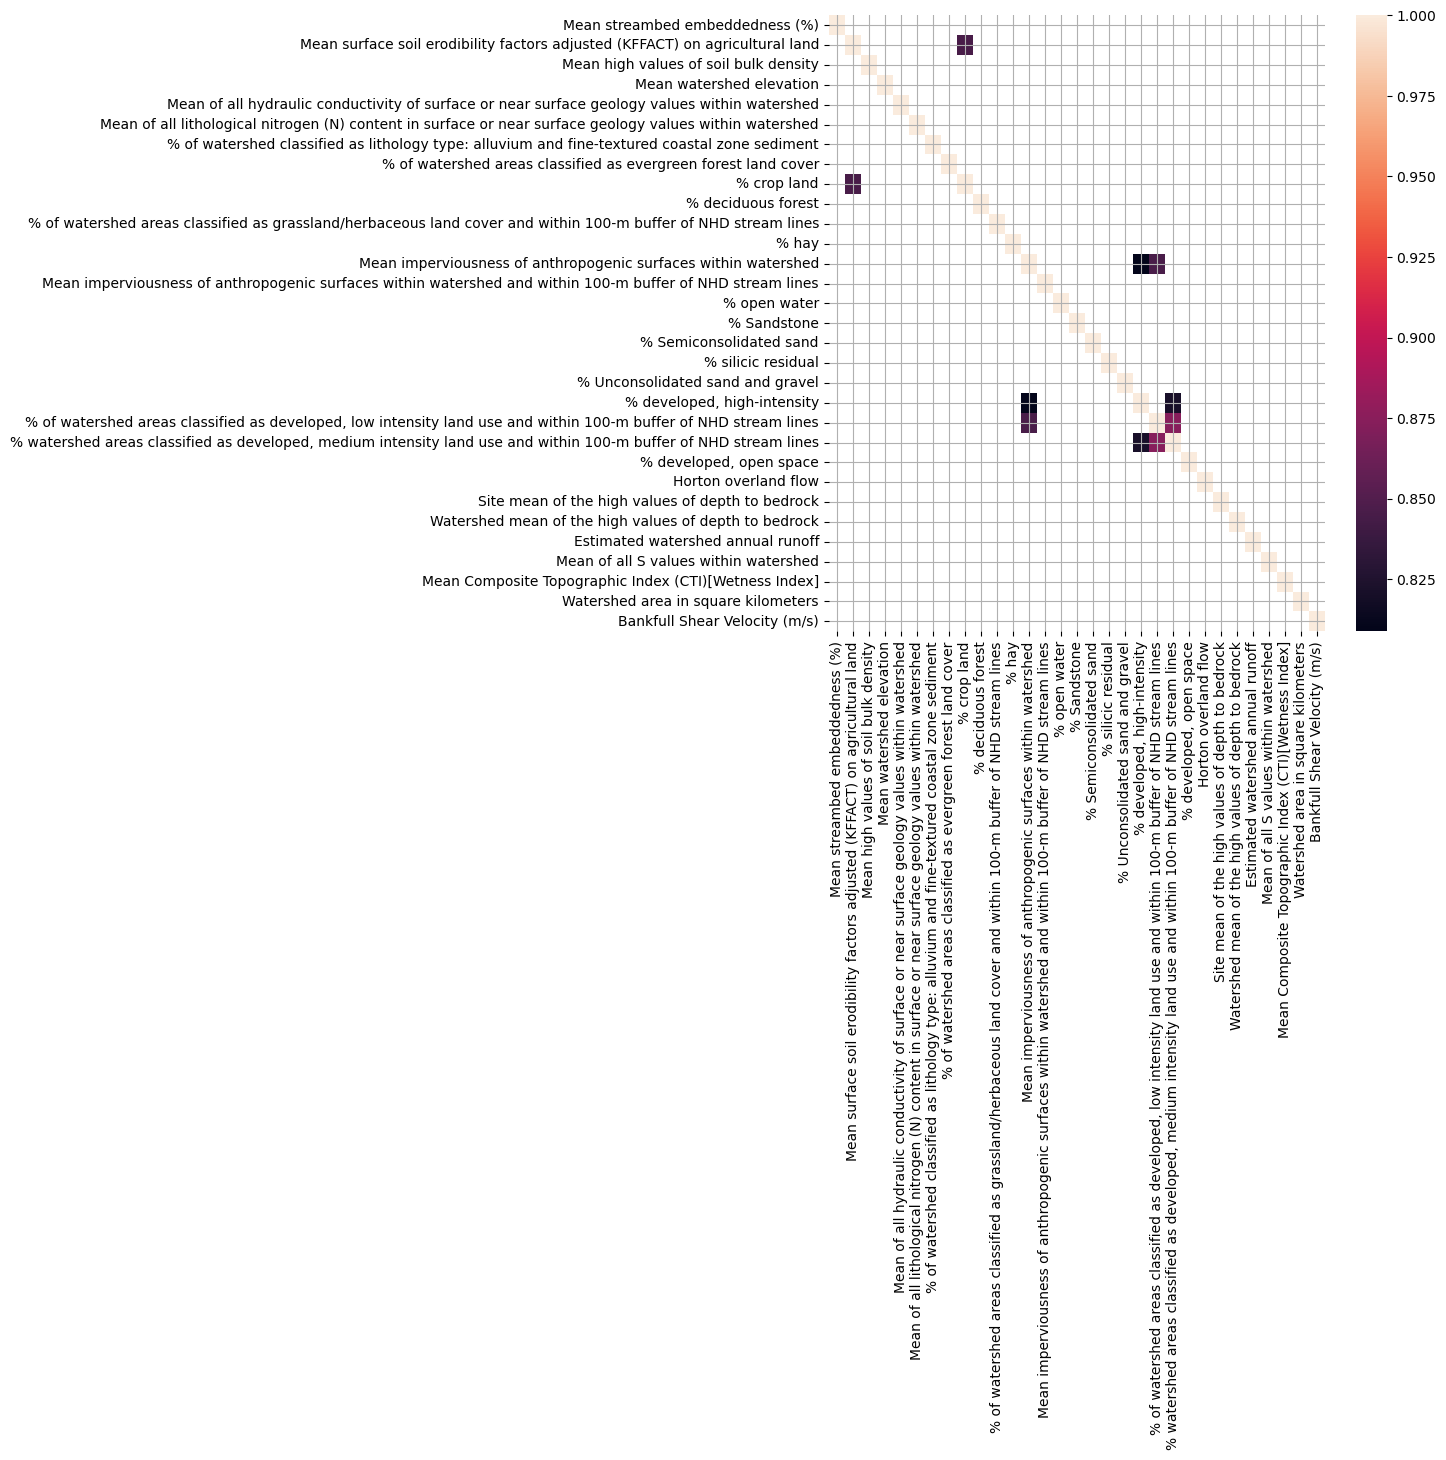

In [15]:
# Set a threshold for filtering based on absolute value
threshold = 0.8

# Keep values greater than 0.8 or less than -0.8
filtered_corr2 = top40_drp1.where(top40_drp1.abs() > threshold)

# Display results
plt.figure(figsize=(8, 8))
sns.heatmap(filtered_corr2)
plt.grid(True)

# Display new df and heatmap
filtered_corr2

##### Pairings with correlations above 0.8:
1. '% crop land' & 'Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land'
2. '% developed, high-intensity' & 'Mean imperviousness of anthropogenic surfaces within watershed'
3. '% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines' & 'Mean imperviousness of anthropogenic surfaces within watershed'
4. '% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines' & '% developed, high-intensity'
5. '% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines' & '% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines'
##### Features to delete from second round:
1. 'Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land' --> more difficult to calculate than % crop land, and slightly lower corr
2. '% developed, high-intensity' --> too specific and a piece of impervious measurement
3. '% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines' --> too specific and a piece of impervious measurement
4. '% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines' --> too specific and a piece of impervious measurement

In [16]:
# Define the list of index rows and columns to drop
to_drop = ['Mean surface soil erodibility factors adjusted (KFFACT) on agricultural land' ,
          '% developed, high-intensity',
          '% of watershed areas classified as developed, low intensity land use and within 100-m buffer of NHD stream lines',
          '% watershed areas classified as developed, medium intensity land use and within 100-m buffer of NHD stream lines']

# Drop specified index rows and columns
top40_drp2 = top40_drp1.drop(index = [i for i in to_drop], 
                             columns = [c for c in to_drop])

# Display updated DataFrame shape (check they were all dropped)
top40_drp2.shape

(27, 27)

,Mean streambed embeddedness (%),Mean high values of soil bulk density,Mean watershed elevation,Mean of all hydraulic conductivity of surface or near surface geology values within watershed,Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,% of watershed areas classified as evergreen forest land cover,% crop land,% deciduous forest,% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines,% open water,% Sandstone,% Semiconsolidated sand,% silicic residual,% Unconsolidated sand and gravel,"% developed, open space",Horton overland flow,Site mean of the high values of depth to bedrock,Watershed mean of the high values of depth to bedrock,Estimated watershed annual runoff,Mean of all S values within watershed,Mean Composite Topographic Index (CTI)[Wetness Index],Watershed area in square kilometers,Bankfull Shear Velocity (m/s)
Mean streambed embeddedness (%),1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean high values of soil bulk density,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean watershed elevation,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all hydraulic conductivity of surface or near surface geology values within watershed,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed areas classified as evergreen forest land cover,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% crop land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% deciduous forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


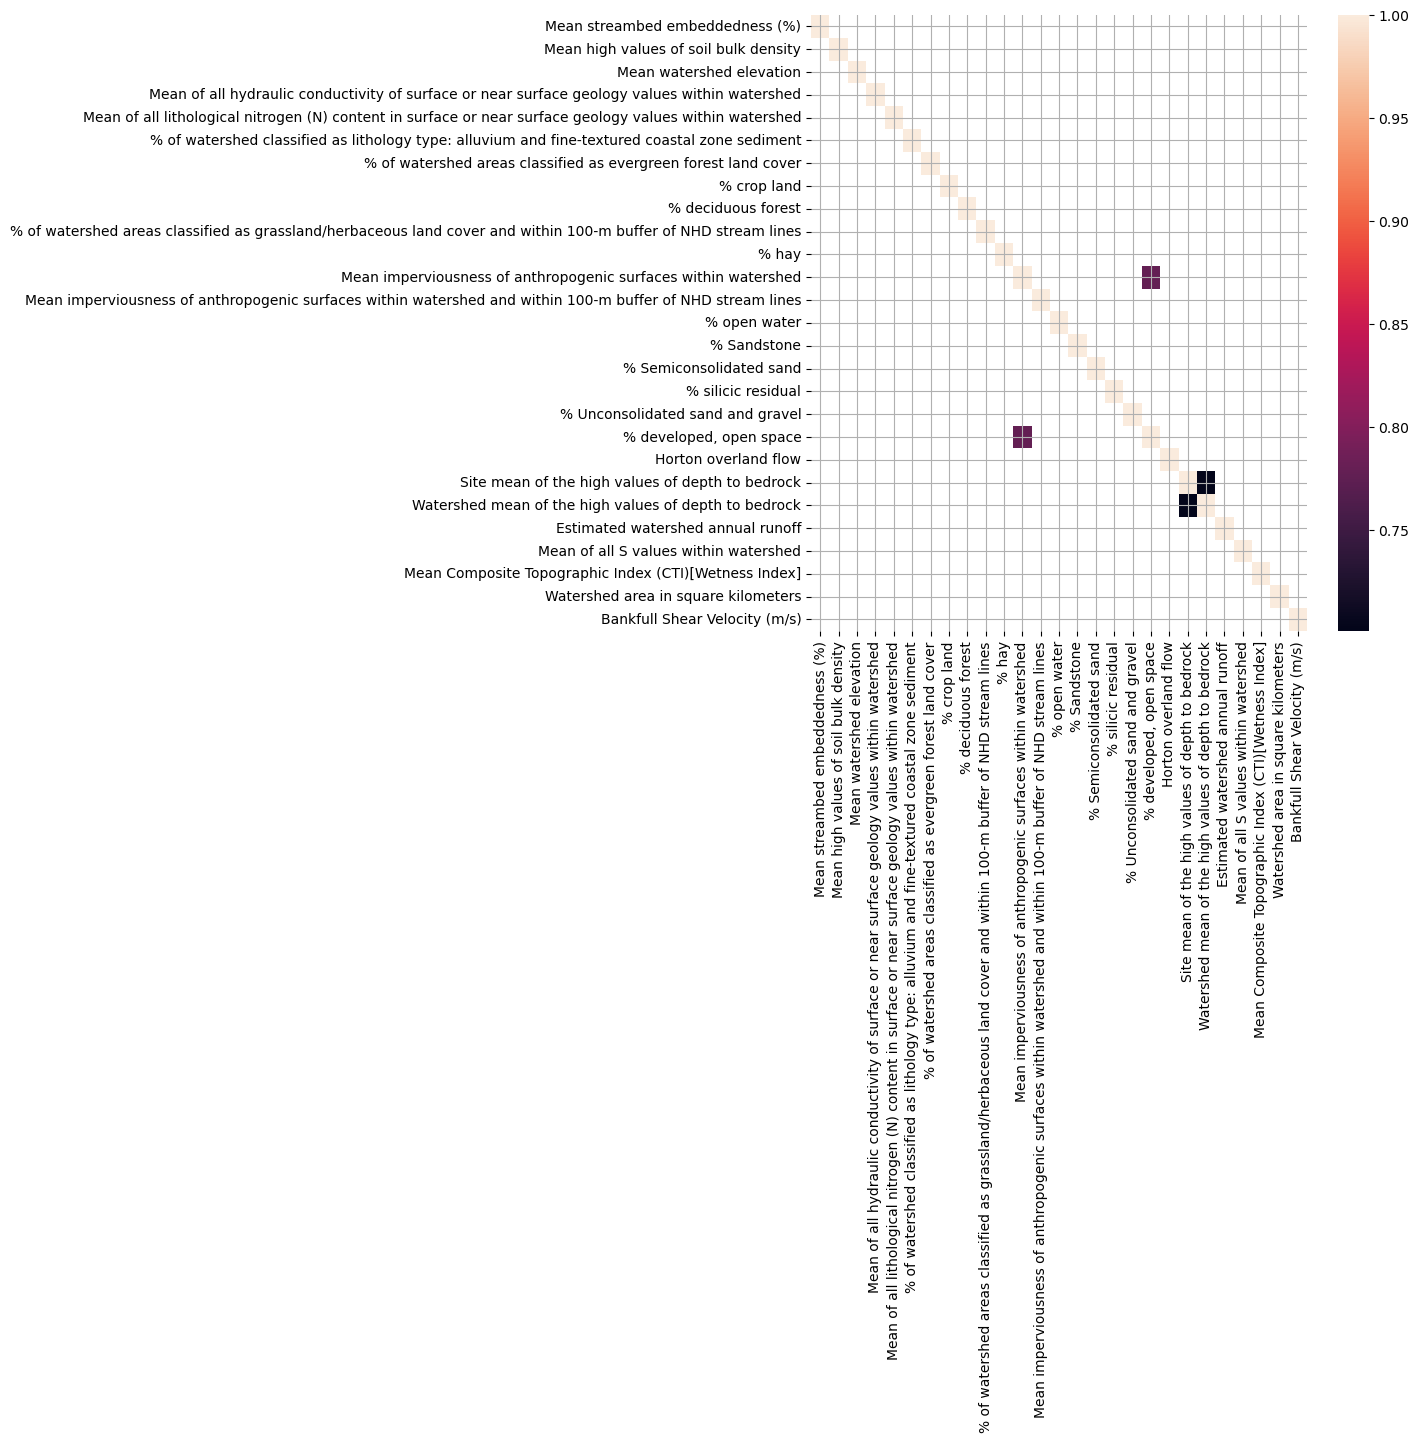

In [17]:
# Set a threshold for filtering based on absolute value
threshold = 0.7

# Keep values greater than 0.7 or less than -0.7
filtered_corr3 = top40_drp2.where(top40_drp2.abs() > threshold)

# Display results
plt.figure(figsize=(8, 8))
sns.heatmap(filtered_corr3)
plt.grid(True)

# Show df and heatmap
filtered_corr3

##### Pairings with correlations above 0.7:
1. 'Watershed mean of the high values of depth to bedrock' & 'Site mean of the high values of depth to bedrock'
2. '% developed, open space' & 'Mean imperviousness of anthropogenic surfaces within watershed'
##### Features to delete from third round:
1. 'Site mean of the high values of depth to bedrock' --> We will try to focus on watershed-wide features for the sake of input calculations
2. '% developed, open space' --> too specific and from imperviousness

In [18]:
# Define the list of index rows and columns to drop
to_drop = ['Site mean of the high values of depth to bedrock',
          '% developed, open space']

# Drop specified index rows and columns
top40_drp3 = top40_drp2.drop(index = [i for i in to_drop], 
                             columns = [c for c in to_drop])

# Display updated DataFrame shape (check they were all dropped)
top40_drp3.shape

(25, 25)

,Mean streambed embeddedness (%),Mean high values of soil bulk density,Mean watershed elevation,Mean of all hydraulic conductivity of surface or near surface geology values within watershed,Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,% of watershed areas classified as evergreen forest land cover,% crop land,% deciduous forest,% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines,% open water,% Sandstone,% Semiconsolidated sand,% silicic residual,% Unconsolidated sand and gravel,Horton overland flow,Watershed mean of the high values of depth to bedrock,Estimated watershed annual runoff,Mean of all S values within watershed,Mean Composite Topographic Index (CTI)[Wetness Index],Watershed area in square kilometers,Bankfull Shear Velocity (m/s)
Mean streambed embeddedness (%),1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.612048
Mean high values of soil bulk density,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean watershed elevation,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.635851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all hydraulic conductivity of surface or near surface geology values within watershed,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed areas classified as evergreen forest land cover,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% crop land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.615636,NaN,NaN
% deciduous forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.694408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


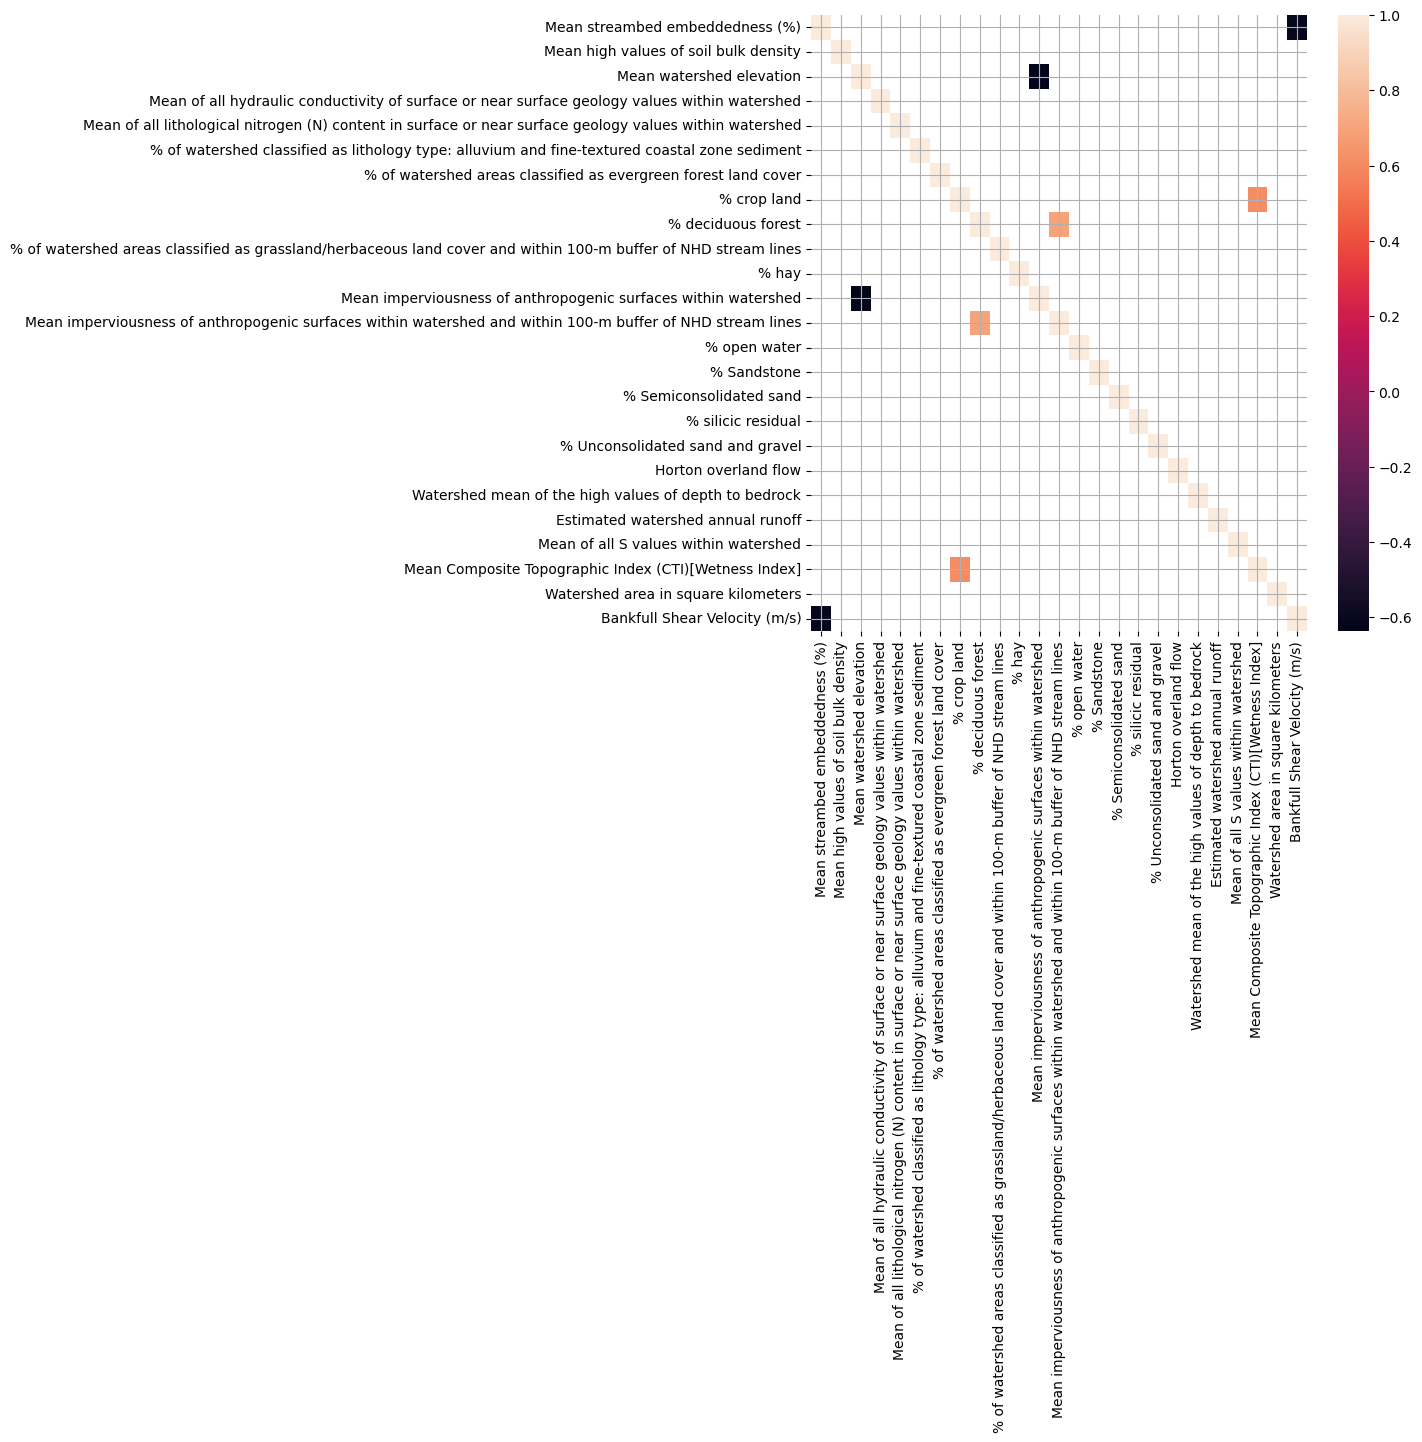

In [19]:
# Set a threshold for filtering based on absolute value
threshold = 0.6

# Keep values greater than 0.6 or less than -0.6
filtered_corr4 = top40_drp3.where(top40_drp3.abs() > threshold)

# Display results
plt.figure(figsize=(8, 8))
sns.heatmap(filtered_corr4)
plt.grid(True)

# Display df and heatmap
filtered_corr4

##### Pairings with correlations above 0.6:
1. 'Mean imperviousness of anthropogenic surfaces within watershed' & 'Mean watershed elevation'
2. 'Mean Composite Topographic Index (CTI)[Wetness Index]' & '% crop land'
3. 'Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines' & '% deciduous forest'
##### Features to delete from third round:
**We won't delete any of the above since we're interested in them. We're going to select the top features we're interested in, then we'll plot some scatter plots to explore further.** 

In [20]:
# Compile final columns and count number of variables identified during correlation EDA
print("The features identified using correlation matrices are:", top40_drp3.index)
print("We have identified", top40_drp3.index.shape[0], "features.")

The features identified using correlation matrices are: Index(['Mean streambed embeddedness (%)',
       'Mean high values of soil bulk density', 'Mean watershed elevation',
       'Mean of all hydraulic conductivity of surface or near surface geology values within watershed',
       'Mean of all lithological nitrogen (N) content in surface or near surface geology values within watershed',
       '% of watershed classified as lithology type: alluvium and fine-textured coastal zone sediment',
       '% of watershed areas classified as evergreen forest land cover',
       '% crop land', '% deciduous forest',
       '% of watershed areas classified as grassland/herbaceous land cover and within 100-m buffer of NHD stream lines',
       '% hay',
       'Mean imperviousness of anthropogenic surfaces within watershed',
       'Mean imperviousness of anthropogenic surfaces within watershed and within 100-m buffer of NHD stream lines',
       '% open water', '% Sandstone', '% Semiconsolidated s

Given our dataset size of only slightly over 1,000 data points, we'll need to trim this down to about 10-15 features. We're going to focus on remotely-calculated features as much as possible. As said earlier, we will continue EDA to select final features.

In [21]:
# Standardize column names by stripping spaces and newlines
epa_1819.columns = epa_1819.columns.str.strip().str.replace("\n", " ")

# Select wanted columns using professional judgement and correlation eda above
epa_1819_trim1 = epa_1819[['Mean streambed embeddedness (%)',
                           'Bankfull Shear Velocity (m/s)', 
                           'Mean high values of soil bulk density', 
                           'Mean watershed elevation',
                           'Mean of all hydraulic conductivity of surface or near surface geology values within watershed',
                           '% of watershed areas classified as evergreen forest land cover',
                           '% crop land', 
                           '% deciduous forest',
                           '% hay',
                           'Mean imperviousness of anthropogenic surfaces within watershed',
                           '% Sandstone', 
                           '% silicic residual', 
                           '% Unconsolidated sand and gravel',
                           'Horton overland flow',
                           'Watershed mean of the high values of depth to bedrock',
                           'Estimated watershed annual runoff',
                           'Mean of all S values within watershed',
                           'Mean Composite Topographic Index (CTI)[Wetness Index]',
                           'Watershed area in square kilometers']]

# Recalculate correlations for these features
corr2 = epa_1819_trim1.corr()
# Select for target
target_corr2 = corr2.abs().loc['Mean streambed embeddedness (%)'].sort_values(ascending = False)
target_corr2

Mean streambed embeddedness (%)                                                                  1.000000
Bankfull Shear Velocity (m/s)                                                                    0.570751
Mean Composite Topographic Index (CTI)[Wetness Index]                                            0.499525
% of watershed areas classified as evergreen forest land cover                                   0.334041
% crop land                                                                                      0.319343
Estimated watershed annual runoff                                                                0.317747
Mean of all hydraulic conductivity of surface or near surface geology values within watershed    0.257743
% silicic residual                                                                               0.236749
Horton overland flow                                                                             0.231348
% Unconsolidated sand and gravel              

### Step 2c. Scatter Plots
We will plot each numerical feature aganst the target. We will first remove the clearly unsuitable features, and hopefully that will get us to the desired number of features.

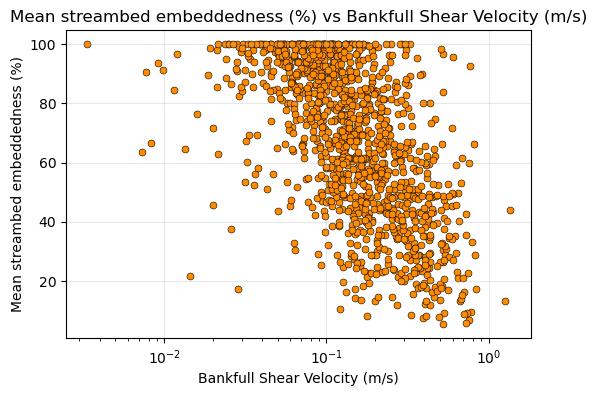

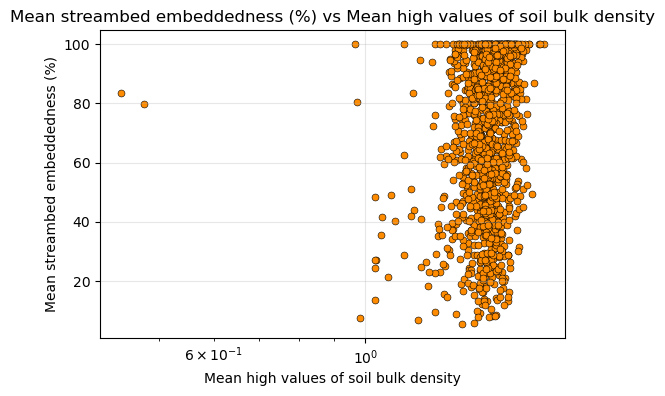

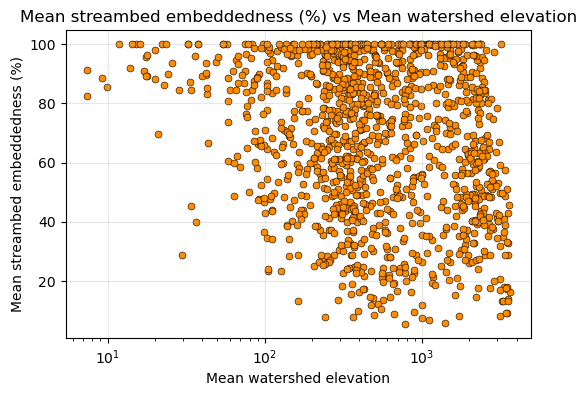

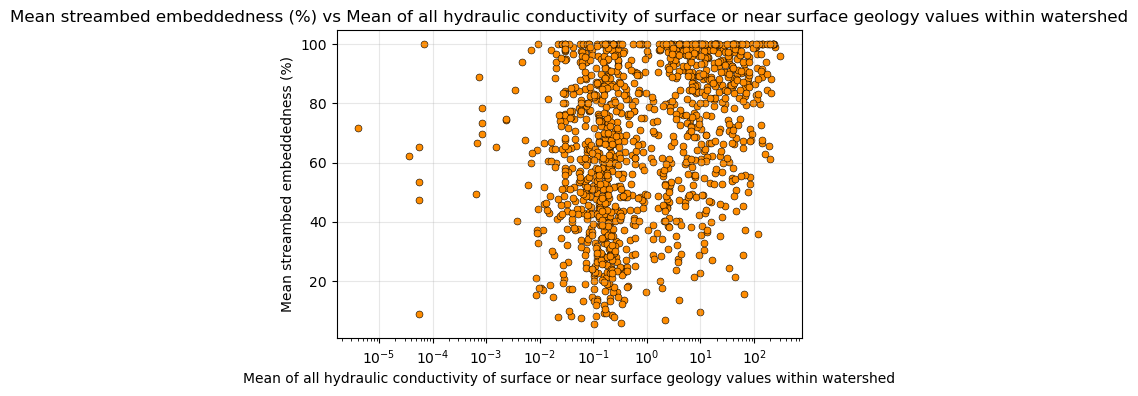

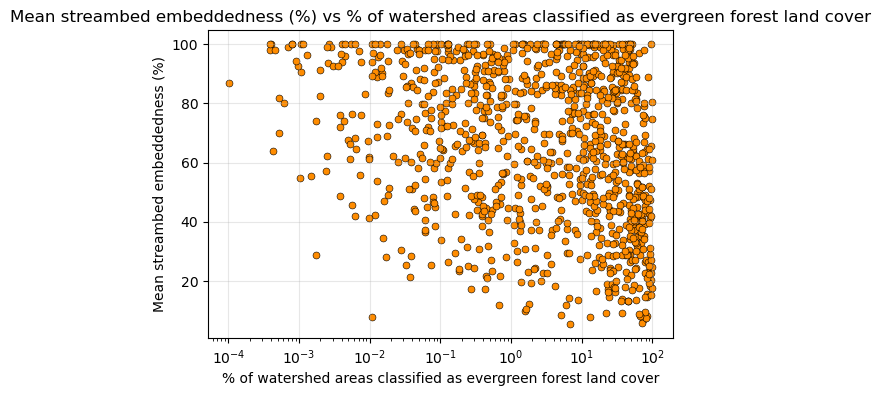

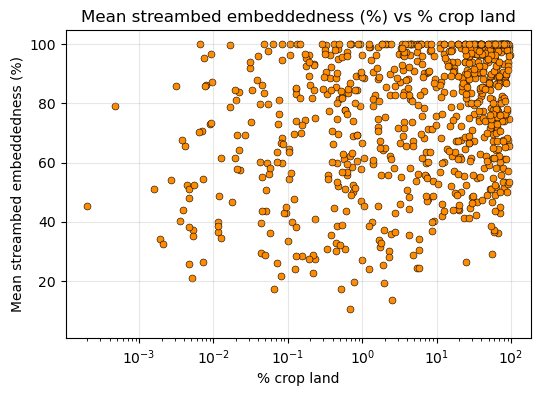

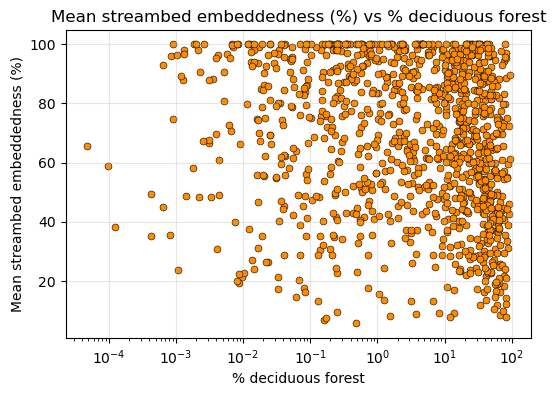

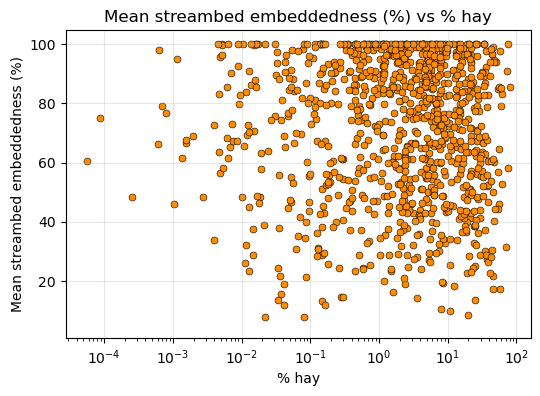

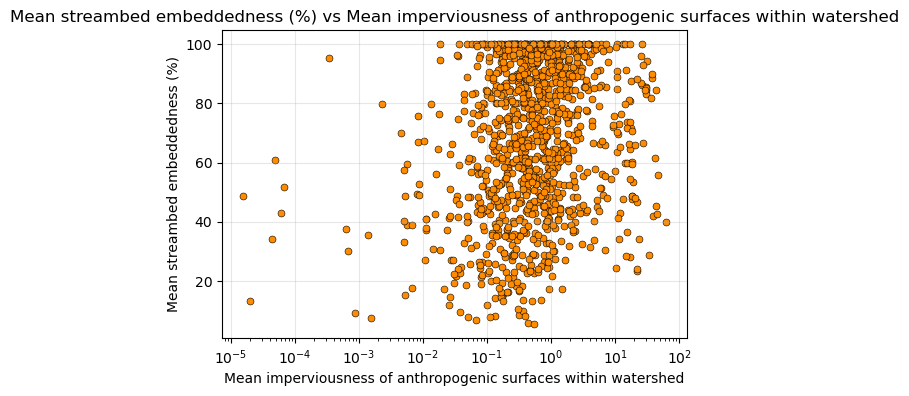

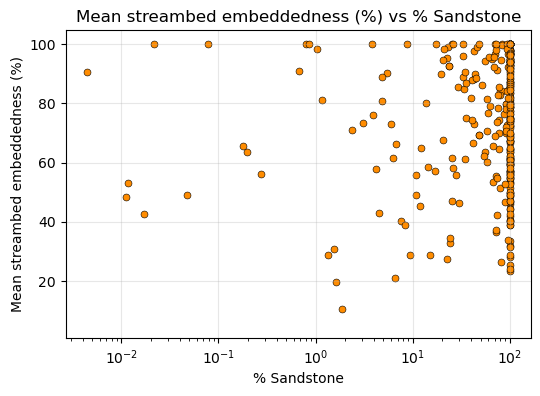

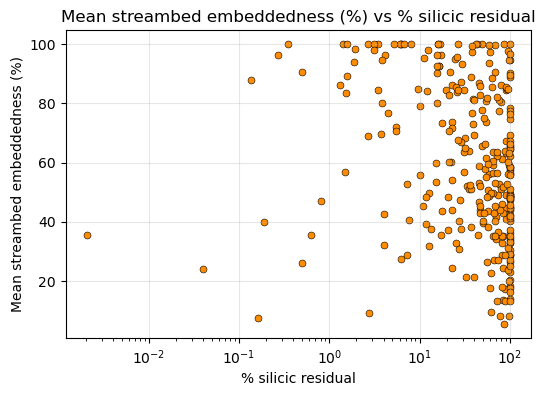

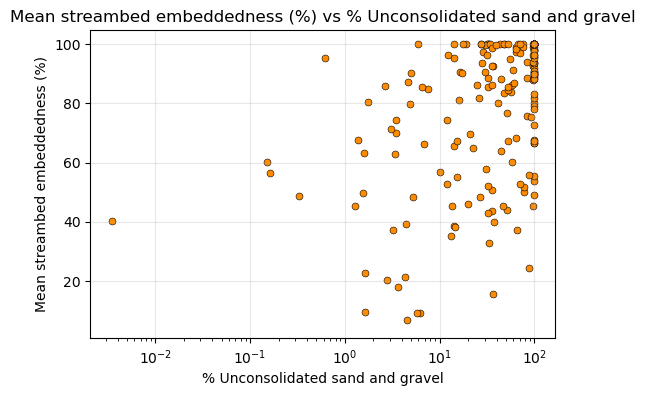

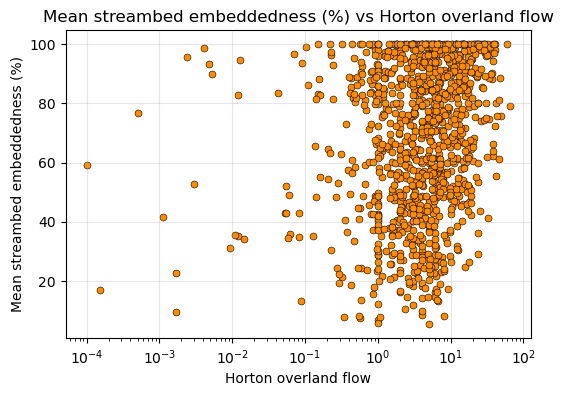

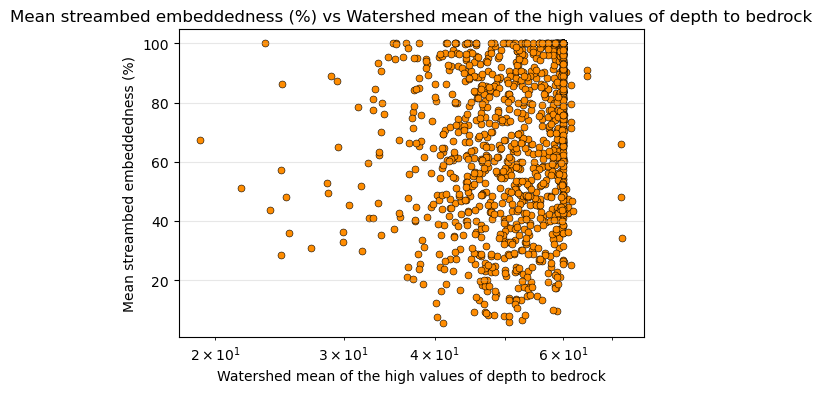

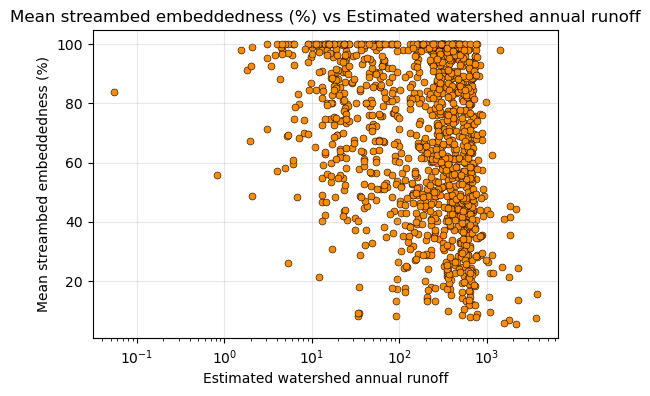

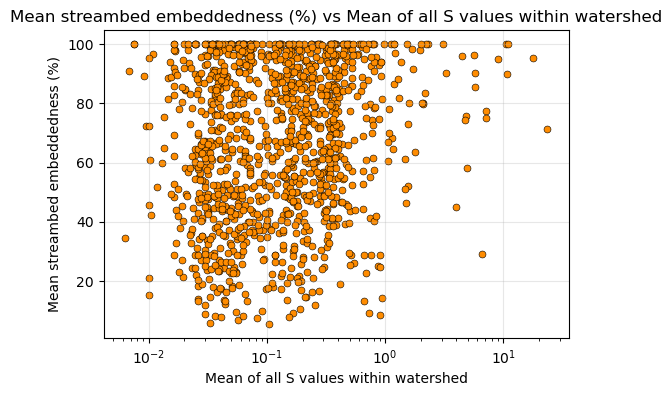

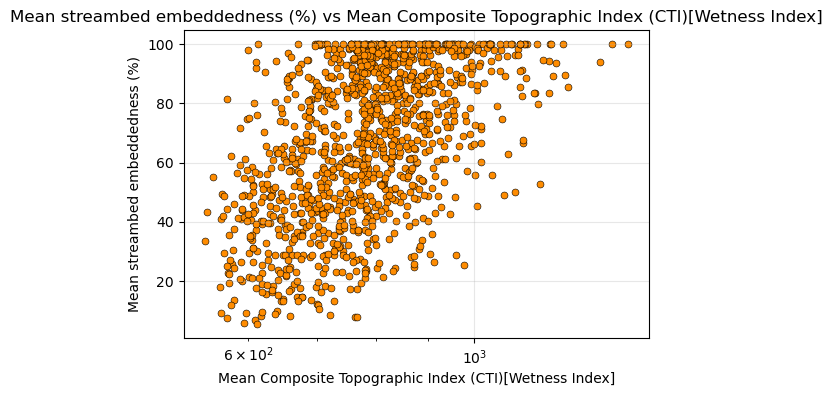

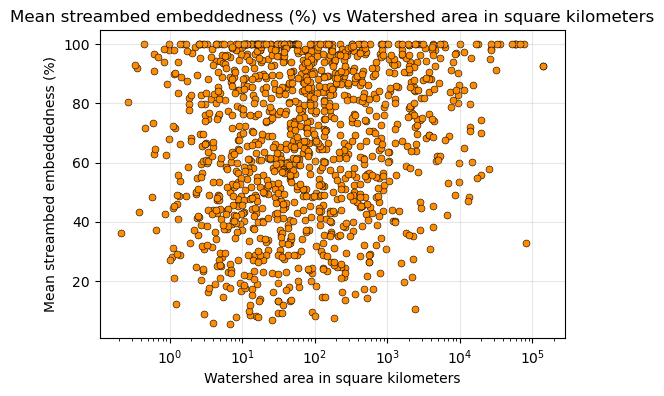

In [22]:
features = [col for col in epa_1819_trim1.columns if col != 'Mean streambed embeddedness (%)']
    
for feature in features:
    plt.figure(figsize=(6, 4))
    
    sns.scatterplot(data = epa_1819_trim1, 
                    x = feature, 
                    y = 'Mean streambed embeddedness (%)', 
                    color = "darkorange", 
                    edgecolor = "black",
                   s = 25)
    
    plt.title(f"{'Mean streambed embeddedness (%)'} vs {feature}")
    plt.xlabel(feature)
    plt.ylabel('Mean streambed embeddedness (%)')
    plt.grid(alpha=0.3)
    plt.xscale('log')
    plt.show()

Features to be removed based on scatter plots:
- '% Sandstone' --> Extreme distribution
- '% slicic residual' --> Extreme distribution
- '% Unconsolidated sand and gravel' --> Even *more* extreme distributihis.
- 'Mean of all S values within watershed' --> An odd, blocky distribution
- 'Watershed area in square kilometers' --> Almost no correla
- 'Horton Overland Flow' --> poor correlation
- 'Depth to bedrock' --> poor correlationtion

In [23]:
# Create gridded scatter plot

# Identify features for scatter plots
sc_df = epa_1819_trim1[['Mean streambed embeddedness (%)', 'Bankfull Shear Velocity (m/s)',
       'Mean high values of soil bulk density', 'Mean watershed elevation',
       'Mean of all hydraulic conductivity of surface or near surface geology values within watershed',
       '% of watershed areas classified as evergreen forest land cover',
       '% crop land', '% deciduous forest', '% hay',
       'Mean imperviousness of anthropogenic surfaces within watershed',
       'Estimated watershed annual runoff',
       'Mean Composite Topographic Index (CTI)[Wetness Index]']]

In [24]:
# Rename column names for plotting
sc_df = sc_df.rename(columns = {'Mean streambed embeddedness (%)':'Streambed Embeddedness (%)',
                                'Bankfull Shear Velocity (m/s)':'Bankfull Shear Velocity',
                               'Mean high values of soil bulk density':'Soil Bulk Density',
                                'Mean watershed elevation':'Avg Watershed Elev',
                               'Mean of all hydraulic conductivity of surface or near surface geology values within watershed':'Hydraulic Conductivity',
                               '% of watershed areas classified as evergreen forest land cover':'% Evergreen Forest',
                               '% crop land':'% Crop Land',
                                '% deciduous forest':'% Deciduous Forest', 
                                '% hay':'% Hay',
                               'Mean imperviousness of anthropogenic surfaces within watershed':'Impervious Surface',
                               'Estimated watershed annual runoff':'Annual Runoff',
                               'Mean Composite Topographic Index (CTI)[Wetness Index]':'CTI'})

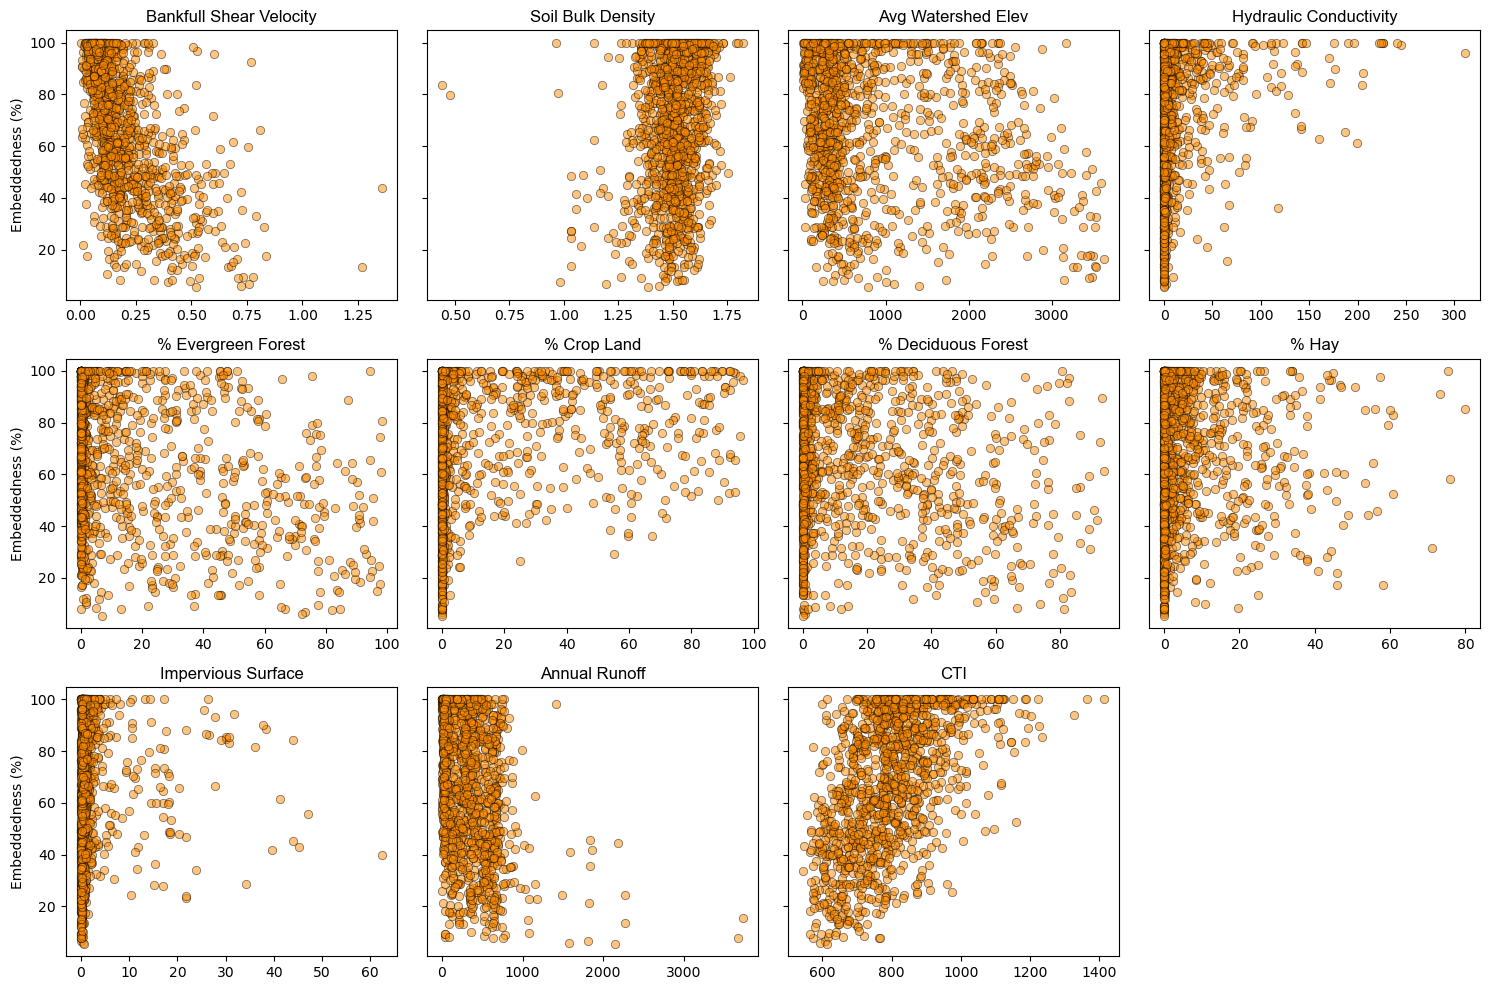

In [25]:
# Identify only features
num_features = ['Bankfull Shear Velocity',
               'Soil Bulk Density', 'Avg Watershed Elev', 'Hydraulic Conductivity',
               '% Evergreen Forest', '% Crop Land', '% Deciduous Forest', '% Hay',
               'Impervious Surface', 'Annual Runoff', 'CTI']

# Set up a 3x4 grid of scatter plots
fig, axes = plt.subplots(3, 4, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, feature in enumerate(num_features):
    ax = axes[i]
    sns.scatterplot(x=sc_df[feature], y=sc_df['Streambed Embeddedness (%)'], 
                    color='darkorange', edgecolor='black', linewidth=0.6, alpha = 0.5, ax=ax)
    ax.set_title(feature, fontsize=12, fontname = 'Arial')
    ax.set_xlabel("")  # Remove x-axis labels
    ax.set_ylabel("Embeddedness (%)" if i % 4 == 0 else "")  # Y-axis label only on the first column

# Remove any unused subplots
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

# Save plot
sctr_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'usepa_feat_scatter_grid.png')
plt.savefig(sctr_path, dpi = 300)

# Display plots
plt.show()

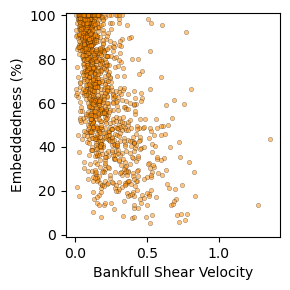

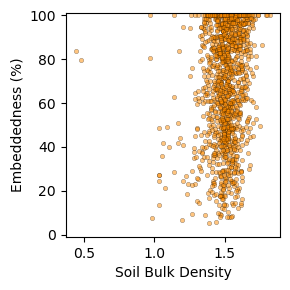

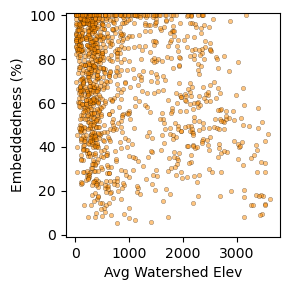

In [26]:
# Additional plotting required for paper

# Define new df for plotting top three correlations
sc_tri_df = sc_df[['Streambed Embeddedness (%)', 'Bankfull Shear Velocity',
                   'Soil Bulk Density', 'Avg Watershed Elev']]
num_features = ['Bankfull Shear Velocity', 'Soil Bulk Density', 'Avg Watershed Elev']

# Loop through to create plots
for feature in num_features:
    plt.figure(figsize=(3,3))
    sns.scatterplot(x=sc_tri_df[feature], y=sc_tri_df['Streambed Embeddedness (%)'], 
                    color='darkorange', edgecolor='black', linewidth=0.3, alpha = 0.5, s=10)
    plt.xlabel(feature)  # Remove x-axis labels
    plt.ylabel("Embeddedness (%)")
    plt.ylim([-1, 101])
    plt.tight_layout()

    # Save plot
    sctr_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', f'usepa_top_three_corr_scatter_{feature}.png')
    plt.savefig(sctr_path, dpi = 300)

# Show plot
plt.show()

#### Required plotting for Paper

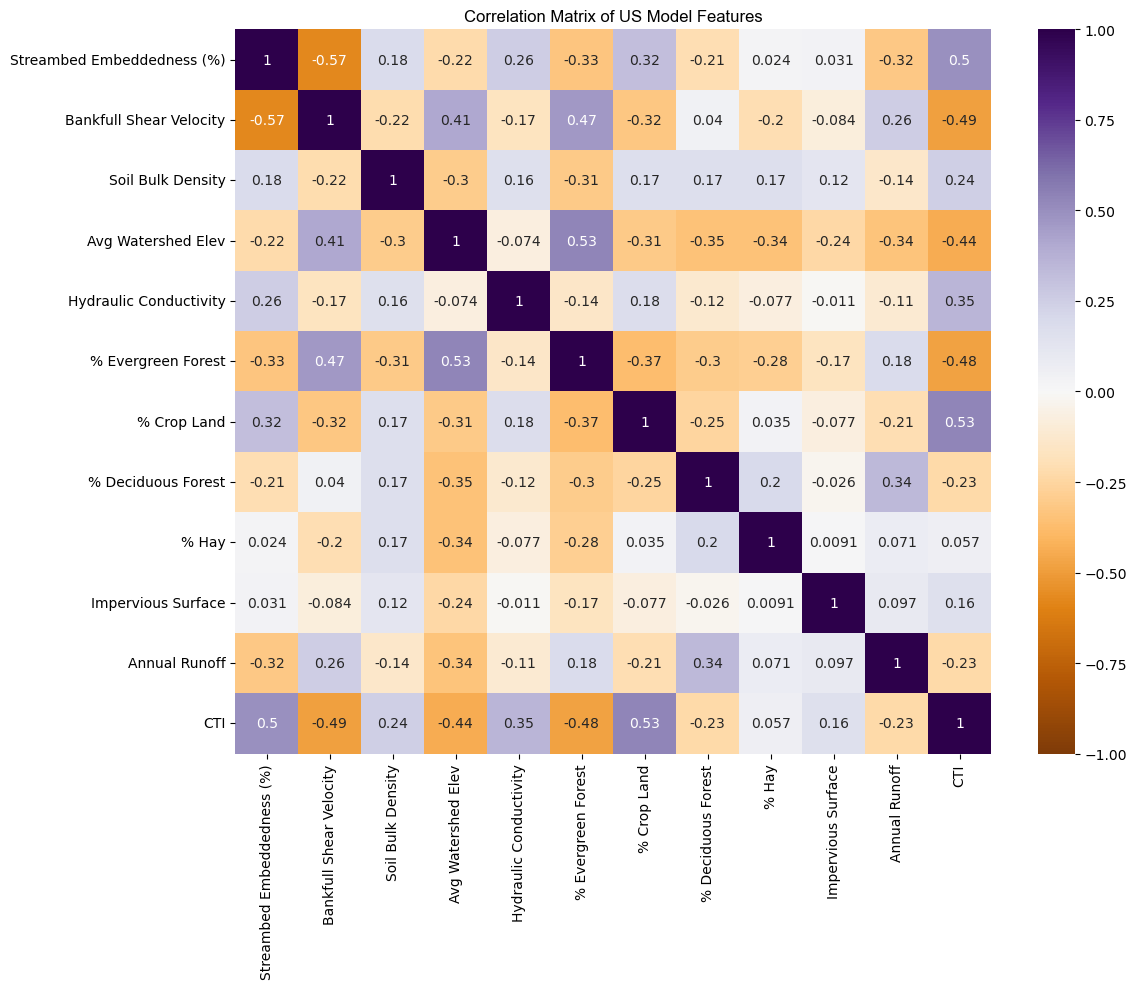

In [34]:
# Create correlation matrix
overall_corr = sc_df.corr()

# Create heatmap
plt.figure(figsize=(12,10))
sns.heatmap(overall_corr,
            cmap = 'PuOr',
           annot = True,
           vmin = -1, vmax = 1)
plt.title('Correlation Matrix of US Model Features', fontname = 'Arial')
plt.tight_layout()

# Save plot
corr_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'us_corr_matrix.png')
plt.savefig(corr_path, dpi = 300)

# Display plot
plt.show()

### Step 2d. Power-Law Fit for Later Model Comparison

In [37]:
# Define the power-law function
def power_law(x, alpha, beta):
    return beta * np.power(x, alpha)

# Filter the data
filtered_data = sc_df[sc_df['Bankfull Shear Velocity'] > 0.1]
filtered_data = filtered_data[filtered_data['Streambed Embeddedness (%)'] != 0]

# Extract the independent and dependent variables
x_data = filtered_data['Bankfull Shear Velocity']
y_data = filtered_data['Streambed Embeddedness (%)']

# Fit the power-law model
popt, pcov = curve_fit(power_law, x_data, y_data)

# Extract the optimal parameters
alpha_opt, beta_opt = popt
print(f"Optimal alpha: {alpha_opt}")
print(f"Optimal beta: {beta_opt}")

# Apply conditional prediction: use model where u* >= 0.1, otherwise assign 100
predicted_Xembed_all = np.where(
    sc_df['Bankfull Shear Velocity'] >= 0.1,
    power_law(sc_df['Bankfull Shear Velocity'], alpha_opt, beta_opt),
    100
)

# Calculate R-squared
residuals = sc_df['Streambed Embeddedness (%)'] - predicted_Xembed_all
ss_res = np.sum(residuals**2)
ss_tot = np.sum((sc_df['Streambed Embeddedness (%)'] - np.mean(sc_df['Streambed Embeddedness (%)']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared: {r_squared}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(sc_df['Streambed Embeddedness (%)'], predicted_Xembed_all))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAE
mae = mean_absolute_error(sc_df['Streambed Embeddedness (%)'], predicted_Xembed_all)
print(f"Mean Absolute Error (MAE): {mae}")

# Sort values for cleaner plotting
sorted_indices = np.argsort(sc_df['Bankfull Shear Velocity'].values)
sorted_u = sc_df['Bankfull Shear Velocity'].values[sorted_indices]
sorted_pred = predicted_Xembed_all[sorted_indices]
beta_round = round(beta_opt, 2)
alpha_round = round(alpha_opt, 2)

Optimal alpha: -0.42397938651180916
Optimal beta: 29.906973767846534
R-squared: 0.2495775499644166
Root Mean Squared Error (RMSE): 22.19348602264194
Mean Absolute Error (MAE): 17.02385100723026


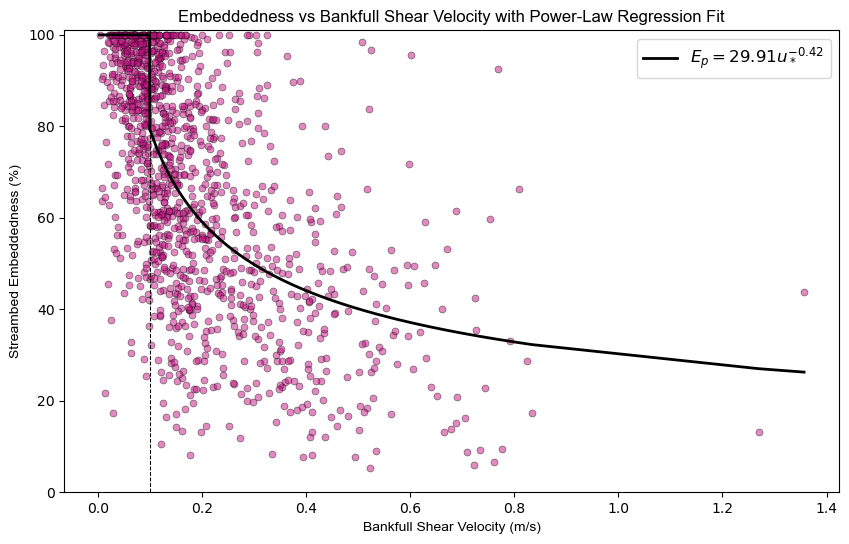

In [39]:
# Plot power-law fit using u*
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Bankfull Shear Velocity', y='Streambed Embeddedness (%)', 
                data=sc_df, edgecolor = 'k', linewidth = 0.5, color = 'mediumvioletred', 
                alpha = 0.5, s = 25)
plt.plot(sorted_u, sorted_pred, color="black", 
         label=rf'$E_p = {beta_round} u_*^{{{alpha_round}}}$', linewidth = 2)
plt.axvline(x=0.1, color='k', linestyle='--', linewidth = 0.75)
plt.ylim(0, 101)
plt.xlabel('Bankfull Shear Velocity (m/s)', fontname = 'Arial')
plt.ylabel('Streambed Embeddedness (%)', fontname = 'Arial')
plt.title('Embeddedness vs Bankfull Shear Velocity with Power-Law Regression Fit', fontname = 'Arial')
plt.legend(fontsize = 12)

# Save plot
powerlaw_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'us_powerlaw.png')
plt.savefig(powerlaw_path, dpi = 300)

# Display plot
plt.show()

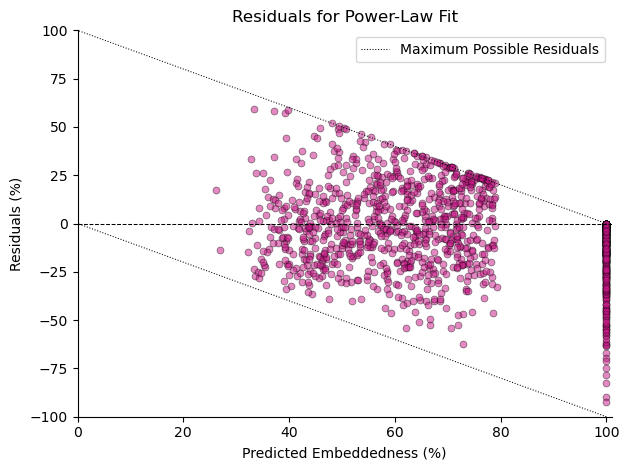

In [40]:
# Plot residuals of power-law fit
plt.scatter(predicted_Xembed_all, residuals, edgecolor = 'k', 
            linewidth = 0.5, color = 'mediumvioletred', alpha = 0.5, s = 25)
plt.xlabel('Predicted Embeddedness (%)')
plt.ylabel('Residuals (%)')
plt.title("Residuals for Power-Law Fit")
plt.axhline(y=0, color='k', linestyle='--', linewidth = 0.75)
plt.ylim([-100, 100])
plt.xlim([0, 101])

# Aesthetics
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75,
        label = 'Maximum Possible Residuals')
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.tight_layout()
plt.legend()

# Save plot
powerlaw_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'us_powerlaw_residuals.png')
plt.savefig(powerlaw_path, dpi = 300)

# Display plot
plt.show()

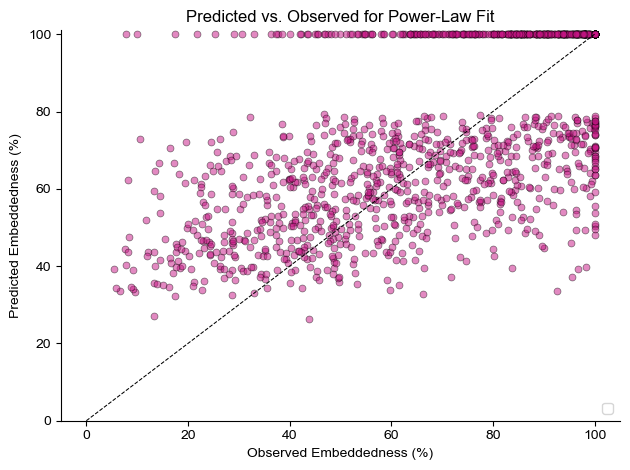

In [41]:
# Plot predictions vs observed for power-law
plt.scatter(sc_df['Streambed Embeddedness (%)'], # observed vals
            predicted_Xembed_all, # predictions
            color = 'mediumvioletred',
            s = 25,
            edgecolors = 'black',
            linewidths = 0.5,
           alpha = 0.5)
plt.xlabel('Observed Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.title('Predicted vs. Observed for Power-Law Fit', fontname = 'Arial')
plt.ylim([0, 101])

# Aesthetics
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
plt.tight_layout()
plt.legend(loc = 'lower right')

# Plot perfect fit
plt.plot([0, 100], [0, 100], 
         color = 'k',
         linestyle = '--',
         linewidth = 0.75,
        label = 'Perfect Fit (1:1)')

# Save plot
powerlaw_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'us_powerlaw_predict_true.png')
plt.savefig(powerlaw_path, dpi = 300)

# Display plot
plt.show()

In [42]:
# Add residuals to sc_df
power_corr = sc_df.copy().drop(columns = ['Streambed Embeddedness (%)','Bankfull Shear Velocity'])
power_corr['Residuals (%)'] = residuals

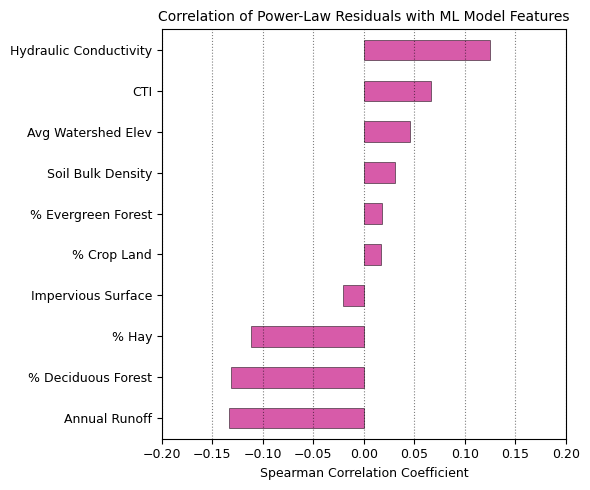

In [43]:
# Select for only numerical values
corr = power_corr.corr(method = 'spearman')

# Select for target
target_corr = corr.loc['Residuals (%)'].sort_values().drop('Residuals (%)')

# Plot the horizontal bar plot
plt.figure(figsize = (6, 5))
target_corr.plot(kind='barh', 
                 color='mediumvioletred', 
                 fontsize = 9,
                alpha = 0.7,
                 edgecolor = 'k',
                linewidth = 0.5)
plt.xlabel('Spearman Correlation Coefficient', fontsize = 9)
plt.xlim([-0.2, 0.2])
plt.title(rf'Correlation of Power-Law Residuals with ML Model Features', fontsize = 10)
plt.grid(axis='x', which='both', linestyle = ':', color = 'k', alpha = 0.5)
plt.tight_layout()

# Save plot
powerlaw_path = os.path.join(BASE_DIR, 'usepa_nrsa', 'eda', 'figures', 'us_powerlaw_residual_corr.png')
plt.savefig(powerlaw_path, dpi = 300)

# Display plot
plt.show()

### Step 2d. Histograms
We have just a couple categorical features in the dataset that we should observe prior to adding to the model. We will also check that the target is normally distributed

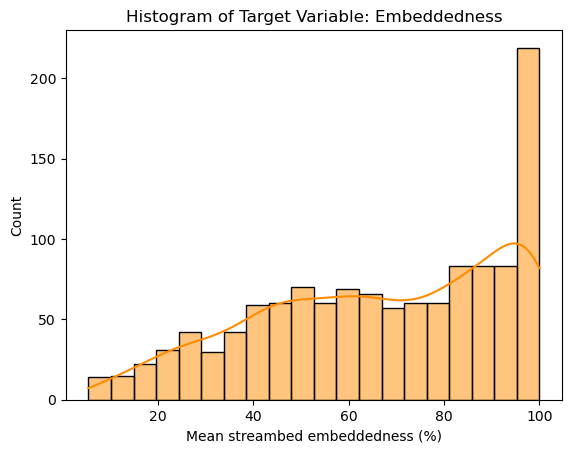

In [45]:
# Historam of target var
sns.histplot(data = epa_1819,
             x = 'Mean streambed embeddedness (%)',
             color = 'darkorange',
            bins = 20,
            kde = True)

plt.title("Histogram of Target Variable: Embeddedness")
plt.xlabel('Mean streambed embeddedness (%)')

# Show figure
plt.show()

Based on the histogram above, we can see that the target, embeddedness, is left-skewed for the national dataset. This is expected given that the dataset encompasses a lot of flat land that can lead to higher embeddedness, versus Virginia where we see a greater variety of slopes/physiographic regions. **We will find a solution for this in the later Feature_Engineering notebook.**

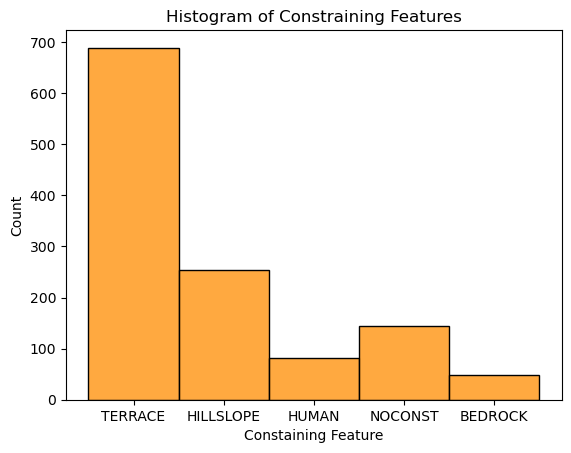

In [46]:
# Histogram of constraining features
sns.histplot(data = epa_1819,
             x = 'Constraining Features',
            color = 'darkorange')

plt.title("Histogram of Constraining Features")
plt.xlabel('Constaining Feature')

# Show figure
plt.show()

We can see that 'terrace' is the dominating constraining feature from the dataset. Since this is found in the field, we likely won't use it in the final model, but it is interesting.

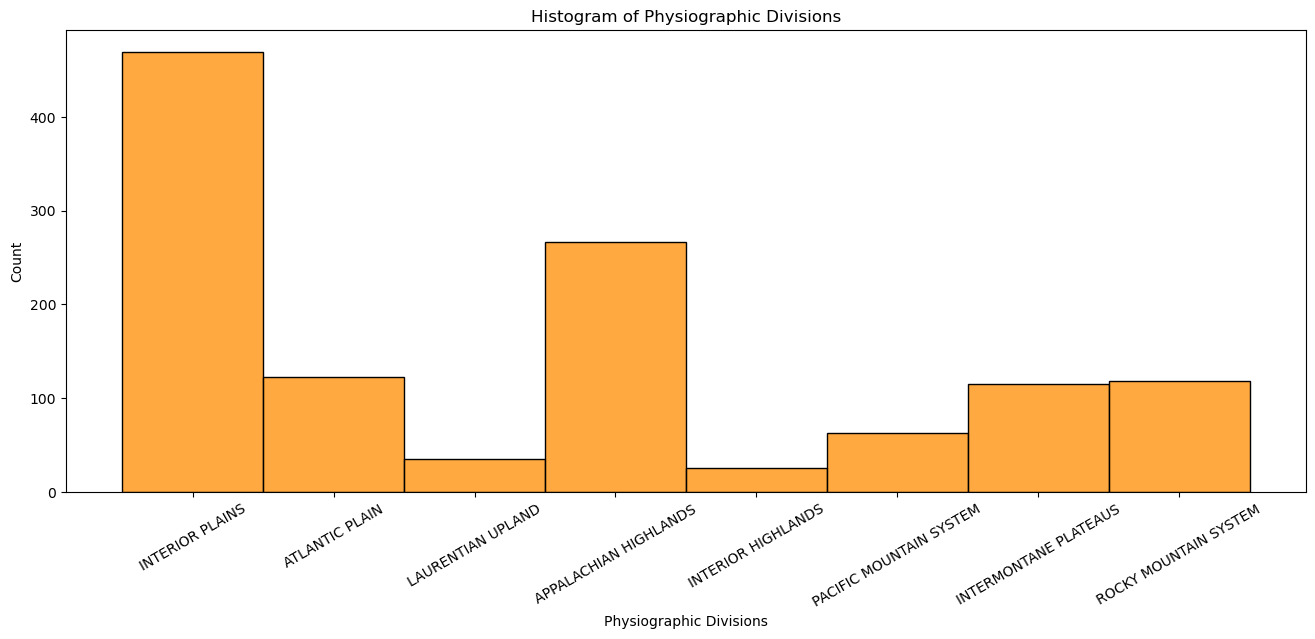

In [47]:
# Histogram of Level 1 Ecoregion
plt.figure(figsize = (16, 6))
sns.histplot(data = epa_1819,
             x = 'DIVISION',
            color = 'darkorange')

plt.title("Histogram of Physiographic Divisions")
plt.xlabel('Physiographic Divisions')
plt.xticks(rotation = 30)

# Show figure
plt.show()

## Step 3. Feature Selection for Model Building
From the results of the EDA, we are going to compile the final dataset to move on to the transformation and model building stage. We will maintain some metadata features (site id, lat/long, date), the target (embeddedness), numerical features, and the categorical features.

In [48]:
# Create a dataframe for EDA with all anticipated features
epa_eda_cln = epa_1819[['Site ID',
                        'Unique ID',
                        'LAT_DD83',
                         'LON_DD83',
                        'Collection Date',
                        'Mean streambed embeddedness (%)',
                       'Bankfull Shear Velocity (m/s)', 
                       'Mean high values of soil bulk density', 
                       'Mean watershed elevation',
                        '% of watershed areas classified as evergreen forest land cover',
                       'Mean of all hydraulic conductivity of surface or near surface geology values within watershed',
                       '% crop land', 
                       '% deciduous forest',
                       '% hay',
                       'Mean imperviousness of anthropogenic surfaces within watershed',
                       'Horton overland flow',
                       'Estimated watershed annual runoff',
                       'Mean Composite Topographic Index (CTI)[Wetness Index]',
                       'DIVISION']]

# Test for nulls
epa_eda_cln.isnull().sum().sort_values(ascending = False)

DIVISION                                                                                         10
LAT_DD83                                                                                         10
LON_DD83                                                                                         10
Bankfull Shear Velocity (m/s)                                                                     7
Horton overland flow                                                                              3
Unique ID                                                                                         1
% deciduous forest                                                                                0
Mean Composite Topographic Index (CTI)[Wetness Index]                                             0
Estimated watershed annual runoff                                                                 0
Mean imperviousness of anthropogenic surfaces within watershed                                    0


Given the low number of nulls, we'll just drop any nulls.

In [49]:
# Drop na values
epa_eda_cln1 = epa_eda_cln.dropna()

# Display dataframe
epa_eda_cln1

,Site ID,Unique ID,LAT_DD83,LON_DD83,Collection Date,Mean streambed embeddedness (%),Bankfull Shear Velocity (m/s),Mean high values of soil bulk density,Mean watershed elevation,% of watershed areas classified as evergreen forest land cover,Mean of all hydraulic conductivity of surface or near surface geology values within watershed,% crop land,% deciduous forest,% hay,Mean imperviousness of anthropogenic surfaces within watershed,Horton overland flow,Estimated watershed annual runoff,Mean Composite Topographic Index (CTI)[Wetness Index],DIVISION
0,NRS18_OK_10062,2014737.0,35.545389,-99.722705,2018-06-20,100.000000,0.136881,1.651461,713.215273,0.000000,4.391568,2.148320,0.000000,0.017187,0.384291,23.797886,15.044169,783.256509,INTERIOR PLAINS
1,NRS18_OK_10431,2012488.0,36.902168,-95.164255,2018-06-25,58.272727,0.099543,1.566628,264.820567,0.129099,0.190633,2.711077,15.375678,75.961787,0.350762,14.686742,316.444229,854.012910,INTERIOR PLAINS
2,NRS18_OK_10025,2012489.0,33.929449,-96.070242,2018-07-02,96.363636,0.243826,1.619647,242.522807,0.404160,1.053346,0.190471,25.591785,21.974691,1.040467,11.814687,258.166777,855.466717,ATLANTIC PLAIN
3,NRS18_WI_10091,2012490.0,42.536868,-89.395560,2018-07-02,53.418182,0.205462,1.541781,270.240009,0.000000,0.057551,82.225514,2.277356,11.034994,0.820033,5.816515,268.000000,781.569154,INTERIOR PLAINS
4,NRS18_WI_10006,2012491.0,45.496257,-87.982493,2018-07-12,83.222222,0.065650,1.477531,361.518160,2.329856,0.399779,0.334325,43.025784,1.453402,0.372214,0.151444,282.252458,882.425172,LAURENTIAN UPLAND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219,NRS18_ND_10676,2014707.0,47.115919,-103.577316,2019-09-24,54.909091,0.076556,1.489619,985.968915,2.022914,11.509658,7.548997,0.637791,2.321166,0.195841,12.643175,20.182804,817.928745,INTERIOR PLAINS
1220,NRS18_PA_10009,2014708.0,41.922584,-77.129228,2019-09-25,38.781818,0.118971,1.512844,535.954972,1.362292,0.146364,0.539690,44.290340,25.256653,1.080702,2.303129,384.760318,745.453162,APPALACHIAN HIGHLANDS
1221,NRS18_SD_10005,2014714.0,43.070132,-98.800398,2019-09-25,61.083333,0.164587,1.318988,560.868431,0.009684,6.580424,19.472869,5.874948,0.971626,0.281433,45.833549,18.789761,749.269473,INTERIOR PLAINS
1222,NRS18_NC_10897,2014715.0,35.996645,-80.336835,2019-09-24,100.000000,0.088388,1.496762,266.633024,2.364878,0.161872,0.877015,21.166792,7.810429,17.165070,6.575107,487.483833,756.213330,APPALACHIAN HIGHLANDS


**The final dataset moving forward has 12 numerical columns and 1 categorical column. There are 1,210 data points.**

## Step 4. Export to Excel for Transformation

In [50]:
# Export trimmed eda dataset
eda_path = os.path.join(BASE_DIR, "data", "processed", "national", "usepa_post_eda_trim.xlsx")
epa_eda_cln1.to_excel(eda_path)
print(f"Dataset saved to {eda_path}")

Dataset saved to C:\Users\reill\Documents\Virginia Tech\Czuba Research\Embeddedness\GitHub\Embeddedness_ML_XAI\data\processed\national\usepa_post_eda_trim.xlsx
